# CBS RLVR — Three Experimental Settings: Comprehensive Analysis

This notebook cleanly separates and analyzes three distinct experimental settings for Critical Batch Size (CBS) in RLVR (GRPO/PPO):

| Setting | Description | Limiting Factor |
|---|---|---|
| **I — Algorithmic CBS** | Fixed `mbs=256`, vary `n_prompts` → `update_ratio = n_prompts/256` changes | Off-policy drift (more gradient steps per stale batch) |
| **II — Statistical CBS** | `mbs = n_prompts` always, `ratio=1` (always on-policy) | Gradient noise `B_noise` |
| **III — Clip Ratio Ablation** | Same setup, vary `clip_ratio` ∈ {0.0, 0.2, 1.0} | Effect of IS-ratio clipping |

**Sections:**
1. Data Loading from W&B
2. Experiment Classification (3 settings)
3. Setting I — Algorithmic CBS
4. Setting II — Statistical CBS
5. Setting III — Clip Ratio Ablation
6. Cross-Setting Comparison
7. Summary

In [35]:
import os, re, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from scipy.optimize import curve_fit
from collections import defaultdict
import wandb

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 13,
    'axes.titlesize': 13,
    'legend.fontsize': 10,
    'figure.dpi': 130,
    'figure.figsize': (7, 4.5),
    'lines.linewidth': 1.8,
})

def smooth(s: pd.Series, w: int = 5) -> pd.Series:
    return s.rolling(window=w, min_periods=1, center=True).mean()

print('imports ok')

imports ok


## 1. Data Loading from W&B

In [36]:
# os.environ['WANDB_API_KEY'] = "..."
# wandb.login()

ENTITY  = 'harvardml'
PROJECT = 'cbs_rlvr'

api  = wandb.Api(timeout=60)
runs = api.runs(f'{ENTITY}/{PROJECT}')
print(f'Found {len(runs)} total runs in {ENTITY}/{PROJECT}')

Found 20 total runs in harvardml/cbs_rlvr


In [37]:
# ── Metric column names ──────────────────────────────────────────────────
STEP_COL     = 'training/global_step'
GSM8K_COL    = 'val-core/OpenMathInstruct-2/gsm8k/reward/mean@1'
MATH_COL     = 'val-core/OpenMathInstruct-2/math/reward/mean@1'
REWARD_COL   = 'critic/rewards/mean'
CLIPFRAC_COL = 'actor/pg_clipfrac'
KL_COL       = 'actor/ppo_kl'
GRADNORM_COL = 'actor/grad_norm'
BNOISE_COL   = 'grad_noise/B_noise_estimate'
BNOISE_APX   = 'grad_noise/B_noise_approx'

# ── Config extractor ──────────────────────────────────────────────────────
def get_cfg(cfg: dict, *keys, default=None):
    """Safely traverse a nested wandb config dict.

    Tries two access patterns in order:
      1. Nested:  cfg['data']['train_batch_size']
      2. Flat:    cfg['data.train_batch_size']   (wandb sometimes flattens)
    Returns `default` if the key path is not found.
    """
    # Nested traversal
    node = cfg
    for k in keys:
        if not isinstance(node, dict) or k not in node:
            node = None
            break
        node = node[k]
    if node is not None:
        return node

    # Flat fallback: join keys with '.' and look for the concatenated key
    flat_key = '.'.join(str(k) for k in keys)
    return cfg.get(flat_key, default)


def meta_from_run(run) -> dict:
    """Extract experiment metadata from a wandb Run object.

    All parameters come from run.config (the logged training config).
    Only `phase` is extracted from the run name, since it encodes the
    experiment phase label and is not present in the training config.
    """
    cfg  = run.config          # nested dict: the full OmegaConf config
    name = run.name

    # Phase label: first token after 'cbs_' and before '_np' in the run name
    phase = None
    if name.startswith('cbs_') and '_np' in name:
        phase = name.split('_np')[0][4:]   # e.g. 'p1', 'p2a', 'p3'

    n_prompts  = get_cfg(cfg, 'data', 'train_batch_size')
    n_rollouts = get_cfg(cfg, 'actor_rollout_ref', 'rollout', 'n')
    mbs        = get_cfg(cfg, 'actor_rollout_ref', 'actor', 'ppo_mini_batch_size')
    ppo_epochs = get_cfg(cfg, 'actor_rollout_ref', 'actor', 'ppo_epochs',    default=1)
    clip_ratio = get_cfg(cfg, 'actor_rollout_ref', 'actor', 'clip_ratio',    default=0.2)
    lr         = get_cfg(cfg, 'actor_rollout_ref', 'actor', 'optim', 'lr',   default=None)

    meta = dict(
        raw_name   = name,
        phase      = phase,
        n_prompts  = int(n_prompts)  if n_prompts  is not None else None,
        n_rollouts = int(n_rollouts) if n_rollouts is not None else None,
        mbs        = int(mbs)        if mbs        is not None else None,
        ppo_epochs = int(ppo_epochs),
        clip_ratio = float(clip_ratio),
        lr         = str(lr) if lr is not None else None,
    )
    if meta['n_prompts'] and meta['n_rollouts']:
        meta['total_batch'] = meta['n_prompts'] * meta['n_rollouts']

    return meta


# ── Smoke test against the expected values from a few run names ───────────
print('meta_from_run uses run.config — smoke test will run after wandb load.')
print('Config keys expected:')
print('  data.train_batch_size           → n_prompts')
print('  actor_rollout_ref.rollout.n     → n_rollouts')
print('  actor_rollout_ref.actor.ppo_mini_batch_size → mbs')
print('  actor_rollout_ref.actor.ppo_epochs          → ppo_epochs')
print('  actor_rollout_ref.actor.clip_ratio          → clip_ratio')
print('  actor_rollout_ref.actor.optim.lr            → lr')

meta_from_run uses run.config — smoke test will run after wandb load.
Config keys expected:
  data.train_batch_size           → n_prompts
  actor_rollout_ref.rollout.n     → n_rollouts
  actor_rollout_ref.actor.ppo_mini_batch_size → mbs
  actor_rollout_ref.actor.ppo_epochs          → ppo_epochs
  actor_rollout_ref.actor.clip_ratio          → clip_ratio
  actor_rollout_ref.actor.optim.lr            → lr


In [38]:
# ── Download and merge run histories ─────────────────────────────────────
raw_by_name = defaultdict(list)

for run in runs:
    meta = meta_from_run(run)
    if meta['phase'] is None:
        print(f'  skip {run.name!r}: no phase label')
        continue
    if meta['n_prompts'] is None:
        print(f'  skip {run.name!r}: n_prompts missing from config')
        continue

    hist = pd.DataFrame(list(run.scan_history(page_size=10000)))
    raw_by_name[run.name].append((meta, hist, run.state))
    print(f'  {run.name}: {len(hist)} rows  state={run.state}'
          f'  np={meta["n_prompts"]}  nr={meta["n_rollouts"]}'
          f'  mbs={meta["mbs"]}  cr={meta["clip_ratio"]}  ep={meta["ppo_epochs"]}')

# ── Smoke-test: print one run's raw config to verify key paths ────────────
for run in runs:
    cfg = run.config
    if cfg:
        print('\n── Sample config keys (first run with non-empty config) ──')
        for top_key in ['data', 'actor_rollout_ref', 'trainer', 'algorithm']:
            if top_key in cfg:
                sub = cfg[top_key]
                if isinstance(sub, dict):
                    print(f'  {top_key}: {list(sub.keys())[:8]}')
                else:
                    print(f'  {top_key}: {sub}')
        break

# ── Merge crashed+resumed runs by name ───────────────────────────────────
experiments = {}
for name, parts in raw_by_name.items():
    meta   = parts[0][0].copy()
    frames = [h for _, h, _ in parts if not h.empty]
    if not frames:
        continue
    combined = pd.concat(frames, ignore_index=True)
    if STEP_COL in combined.columns:
        combined = (combined.sort_values(STEP_COL)
                    .drop_duplicates(STEP_COL, keep='last')
                    .reset_index(drop=True))
    meta['history'] = combined
    meta['n_parts'] = len(parts)
    experiments[name] = meta

print(f'\nTotal experiments loaded: {len(experiments)}')

# ── Filter to the batch sizes of interest ────────────────────────────────
KEEP_NP = {32, 64, 128, 256, 512, 1024}
before  = len(experiments)
experiments = {k: v for k, v in experiments.items() if v['n_prompts'] in KEEP_NP}
print(f'After filtering to n_prompts ∈ {sorted(KEEP_NP)}: {len(experiments)} experiments'
      f' (dropped {before - len(experiments)})')

  cbs_p1_np256_nr8_lr1e-6: 3 rows  state=crashed  np=256  nr=8  mbs=256  cr=0.2  ep=1
  cbs_p1_np256_nr8_lr1e-6: 1899 rows  state=crashed  np=256  nr=8  mbs=256  cr=0.2  ep=1
  cbs_p1_np512_nr8_lr1e-6: 1199 rows  state=crashed  np=512  nr=8  mbs=256  cr=0.2  ep=1
  cbs_p1_np1024_nr8_lr1e-6: 699 rows  state=crashed  np=1024  nr=8  mbs=256  cr=0.2  ep=1
  cbs_p1_np32_nr8_lr1e-6: 4699 rows  state=crashed  np=32  nr=8  mbs=32  cr=0.2  ep=1
  cbs_p1_np512_nr8_lr1e-6: 921 rows  state=crashed  np=512  nr=8  mbs=256  cr=0.2  ep=1
  cbs_p1_np256_nr8_lr1e-6: 1353 rows  state=crashed  np=256  nr=8  mbs=256  cr=0.2  ep=1
  cbs_p1_np1024_nr8_lr1e-6: 504 rows  state=crashed  np=1024  nr=8  mbs=256  cr=0.2  ep=1
  cbs_p1_np32_nr8_lr1e-6: 10 rows  state=crashed  np=32  nr=8  mbs=32  cr=0.2  ep=1
  cbs_p1_np64_nr8_lr1e-6: 1599 rows  state=crashed  np=64  nr=8  mbs=64  cr=0.2  ep=1
  cbs_p1_np128_nr8_lr1e-6: 1399 rows  state=crashed  np=128  nr=8  mbs=128  cr=0.2  ep=1
  cbs_p1_np32_nr8_lr1e-6: 399 rows

## 2. Experiment Classification

We classify every run into one or more of the three experimental settings based on the
**effective mini-batch size** (`mbs_eff`) and **update ratio** (gradient steps per rollout batch):

```
update_ratio = (n_prompts / mbs_eff) × ppo_epochs
```

| Setting | Criterion | Interpretation |
|---|---|---|
| **I — Algorithmic CBS** | `mbs_eff = min(n_prompts, 256)`, cr=0.2, ep=1 | Standard sweep; for np>256 ratio>1 → algorithmic regime |
| **II — Statistical CBS** | `update_ratio = 1` (mbs=n_prompts), cr=0.2, ep=1 | Always on-policy; only gradient noise limits CBS |
| **III — Clip Ablation** | `clip_ratio ≠ 0.2` | Same as I or II, different clip threshold |

Note: small-batch runs (np ≤ 256) appear in **both** I and II because `mbs = np = min(np, 256)` → ratio=1 naturally.

In [39]:
ALGO_MBS = 256  # fixed mini-batch size for the algorithmic CBS sweep

for name, meta in experiments.items():
    np_val  = meta['n_prompts']
    ep_val  = meta['ppo_epochs']
    # mbs comes directly from the wandb config.
    # Fall back to min(np, 256) only if the config field was absent (old runs).
    mbs_eff = meta['mbs'] # if meta['mbs'] is not None else min(np_val, ALGO_MBS)
    meta['mbs_eff']      = mbs_eff
    meta['update_ratio'] = (np_val / mbs_eff) * ep_val

# ── Three experiment sets ─────────────────────────────────────────────────
# Setting I:  Standard sweep — mbs_eff = min(np, 256), cr=0.2, ep=1
algo_exps = {k: v for k, v in experiments.items()
             if abs(v['clip_ratio'] - 0.2) < 1e-6
             and v['ppo_epochs'] == 1
             and v['mbs_eff'] == min(v['n_prompts'], ALGO_MBS)}

# Setting II: On-policy sweep — mbs = n_prompts (ratio=1), cr=0.2, ep=1
stat_exps = {k: v for k, v in experiments.items()
             if abs(v['clip_ratio'] - 0.2) < 1e-6
             and v['ppo_epochs'] == 1
             and abs(v['update_ratio'] - 1.0) < 1e-6}

# Setting III: Clip ratio ablation — cr ≠ 0.2
clip_exps = {k: v for k, v in experiments.items()
             if abs(v['clip_ratio'] - 0.2) >= 1e-6}

print(f'Setting I   (Algorithmic CBS): {len(algo_exps)} experiments')
print(f'Setting II  (Statistical CBS): {len(stat_exps)} experiments')
print(f'Setting III (Clip ablation):   {len(clip_exps)} experiments')
print()
print('mbs source: wandb run.config (fallback: min(np, 256) for runs without config)')
print('Overlap: np≤256 runs appear in both I and II (ratio=1 by construction)')

Setting I   (Algorithmic CBS): 6 experiments
Setting II  (Statistical CBS): 5 experiments
Setting III (Clip ablation):   1 experiments

mbs source: wandb run.config (fallback: min(np, 256) for runs without config)
Overlap: np≤256 runs appear in both I and II (ratio=1 by construction)


In [40]:
rows = []
for name, meta in sorted(experiments.items(),
                          key=lambda x: (x[1]['clip_ratio'],
                                         x[1].get('update_ratio', 0),
                                         x[1].get('n_prompts', 0))):
    hist = meta['history']
    def _max(c): return round(hist[c].dropna().max(), 3)         if c in hist.columns and not hist[c].dropna().empty else float('nan')

    flags = []
    if name in algo_exps: flags.append('I-Algo')
    if name in stat_exps: flags.append('II-Stat')
    if name in clip_exps: flags.append('III-Clip')

    rows.append({
        'setting':  '+'.join(flags),
        'np':       meta['n_prompts'],
        'mbs':      meta['mbs_eff'],
        'ratio':    round(meta['update_ratio'], 2),
        'cr':       meta['clip_ratio'],
        'B':        meta.get('total_batch'),
        'steps':    int(hist[STEP_COL].dropna().max()) if STEP_COL in hist.columns else 0,
        'gsm8k':    _max(GSM8K_COL),
        'math':     _max(MATH_COL),
    })

print(pd.DataFrame(rows).to_string(index=False))

       setting   np  mbs  ratio  cr    B  steps  gsm8k  math
      III-Clip 1024  256    4.0 0.0 8192    946  0.679 0.151
I-Algo+II-Stat   32   32    1.0 0.2  256   5968  0.645 0.140
I-Algo+II-Stat   64   64    1.0 0.2  512   8696  0.686 0.157
I-Algo+II-Stat  128  128    1.0 0.2 1024   7710  0.694 0.153
I-Algo+II-Stat  256  256    1.0 0.2 2048   3152  0.674 0.143
       II-Stat 1024 1024    1.0 0.2 8192   1118  0.662 0.161
        I-Algo  512  256    2.0 0.2 4096   2020  0.683 0.149
        I-Algo 1024  256    4.0 0.2 8192   1103  0.688 0.156


---
## Setting I — Algorithmic CBS

**Design:** Fixed `mbs = min(n_prompts, 256)`, varying `n_prompts` ∈ {32, 64, 128, 256, 512, 1024}, `n_rollouts=8`, `cr=0.2`, `ep=1`.

**Key mechanism:** The update ratio `= n_prompts / mbs` changes the number of gradient steps applied to the *same* rollout buffer per training iteration:
- `np ≤ 256`: ratio=1 (one gradient step per batch — on-policy)
- `np = 512`: ratio=2 (two gradient steps — mild off-policy)
- `np = 1024`: ratio=4 (four gradient steps — stronger off-policy)

**Diagnostic questions:**
- Do `pg_clipfrac` and `ppo_kl` grow with update_ratio?
- Does learning efficiency (steps-to-threshold) saturate or degrade at high ratio?
- What is the "algorithmic CBS" — the ratio at which off-policy drift hurts?

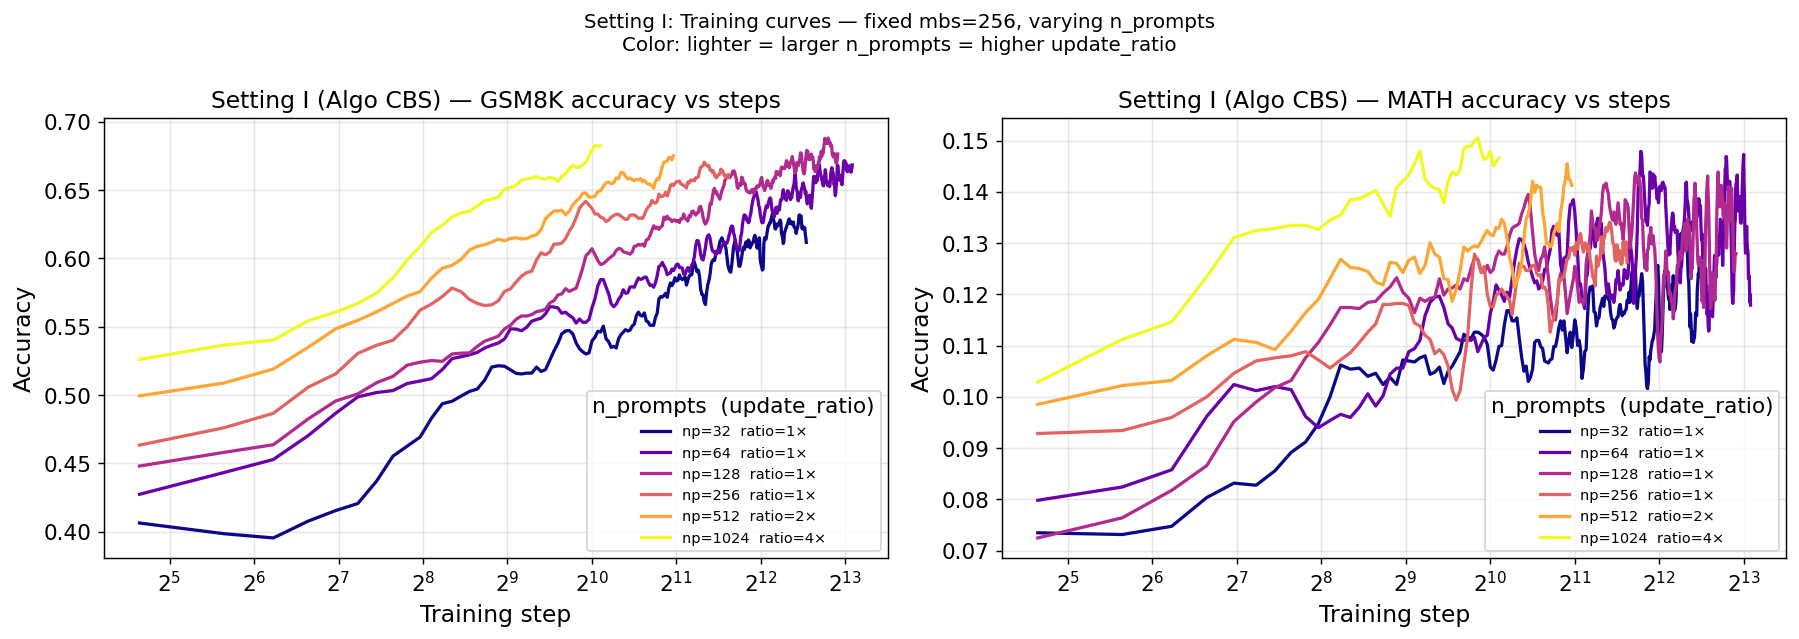

In [41]:
# Color by n_prompts (lighter = more prompts = higher update_ratio)
np_vals_algo = sorted({m['n_prompts'] for m in algo_exps.values()})
ALGO_COLORS  = {np_val: plt.cm.plasma(i / max(len(np_vals_algo)-1, 1))
                for i, np_val in enumerate(np_vals_algo)}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for meta in sorted(algo_exps.values(), key=lambda m: m['n_prompts']):
    hist = meta['history']
    c    = ALGO_COLORS[meta['n_prompts']]
    lbl  = f"np={meta['n_prompts']}  ratio={meta['update_ratio']:.0f}×"
    for ax, col in [(axes[0], GSM8K_COL), (axes[1], MATH_COL)]:
        df = hist[[STEP_COL, col]].dropna().sort_values(STEP_COL)
        if df.empty: continue
        ax.plot(df[STEP_COL], smooth(df[col]), color=c, label=lbl)
        ax.set_xscale('log', base=2)

for ax, title in zip(axes, ['GSM8K accuracy vs steps', 'MATH accuracy vs steps']):
    ax.set_xlabel('Training step')
    ax.set_ylabel('Accuracy')
    ax.set_title(f'Setting I (Algo CBS) — {title}')
    ax.legend(fontsize=8, title='n_prompts  (update_ratio)')
    ax.grid(alpha=.3)

plt.suptitle('Setting I: Training curves — fixed mbs=256, varying n_prompts\n'
             'Color: lighter = larger n_prompts = higher update_ratio', fontsize=11)
plt.tight_layout()
plt.savefig('fig_I_accuracy_vs_steps.pdf', bbox_inches='tight')
plt.show()

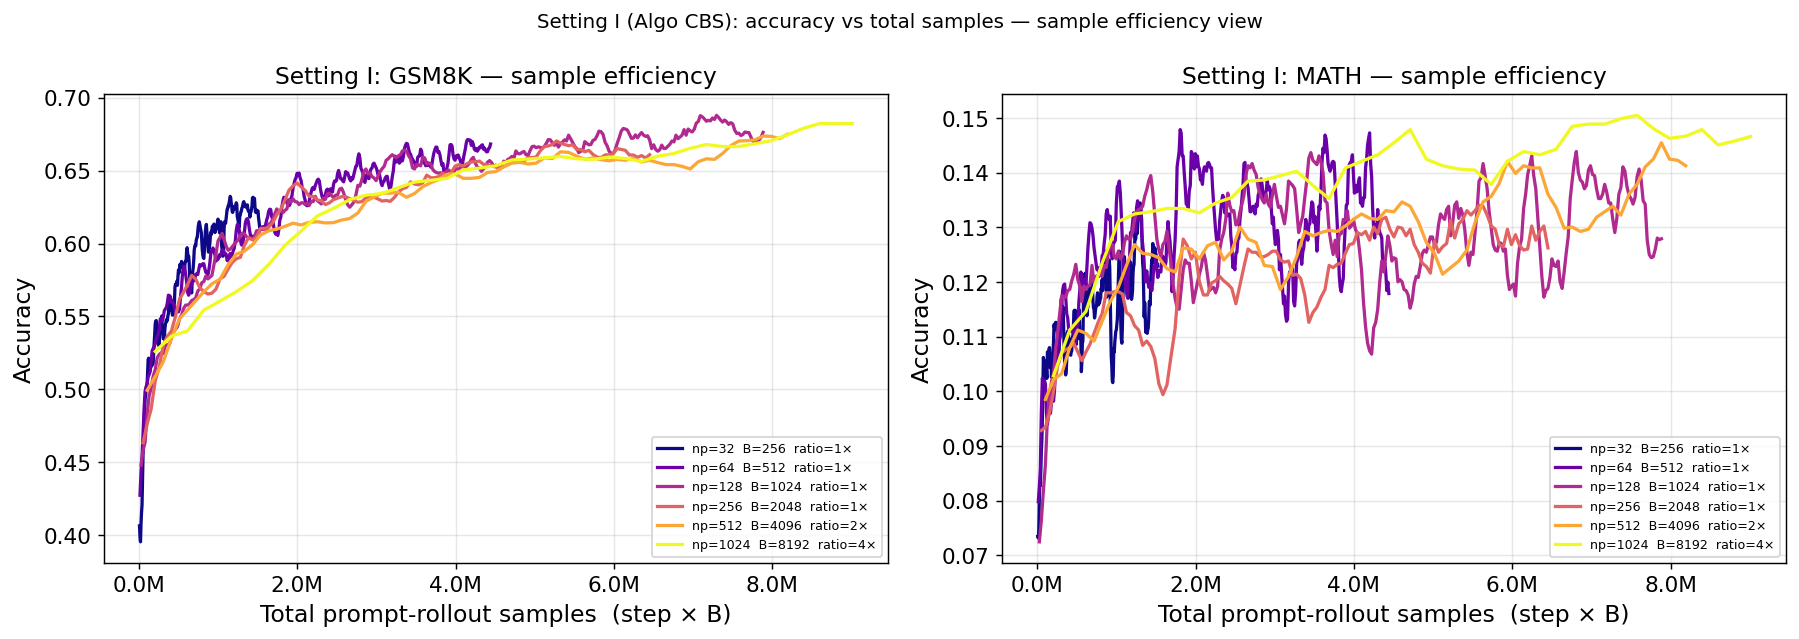

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for meta in sorted(algo_exps.values(), key=lambda m: m['n_prompts']):
    hist = meta['history']
    B    = meta['total_batch']
    c    = ALGO_COLORS[meta['n_prompts']]
    lbl  = f"np={meta['n_prompts']}  B={B}  ratio={meta['update_ratio']:.0f}×"
    for ax, col in [(axes[0], GSM8K_COL), (axes[1], MATH_COL)]:
        df = hist[[STEP_COL, col]].dropna().sort_values(STEP_COL)
        if df.empty: continue
        ax.plot(df[STEP_COL] * B, smooth(df[col]), color=c, label=lbl)

for ax, title in zip(axes, ['GSM8K', 'MATH']):
    ax.set_xlabel('Total prompt-rollout samples  (step × B)')
    ax.set_ylabel('Accuracy')
    ax.set_title(f'Setting I: {title} — sample efficiency')
    ax.legend(fontsize=7)
    ax.grid(alpha=.3)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

plt.suptitle('Setting I (Algo CBS): accuracy vs total samples — sample efficiency view', fontsize=11)
plt.tight_layout()
plt.savefig('fig_I_accuracy_vs_samples.pdf', bbox_inches='tight')
plt.show()

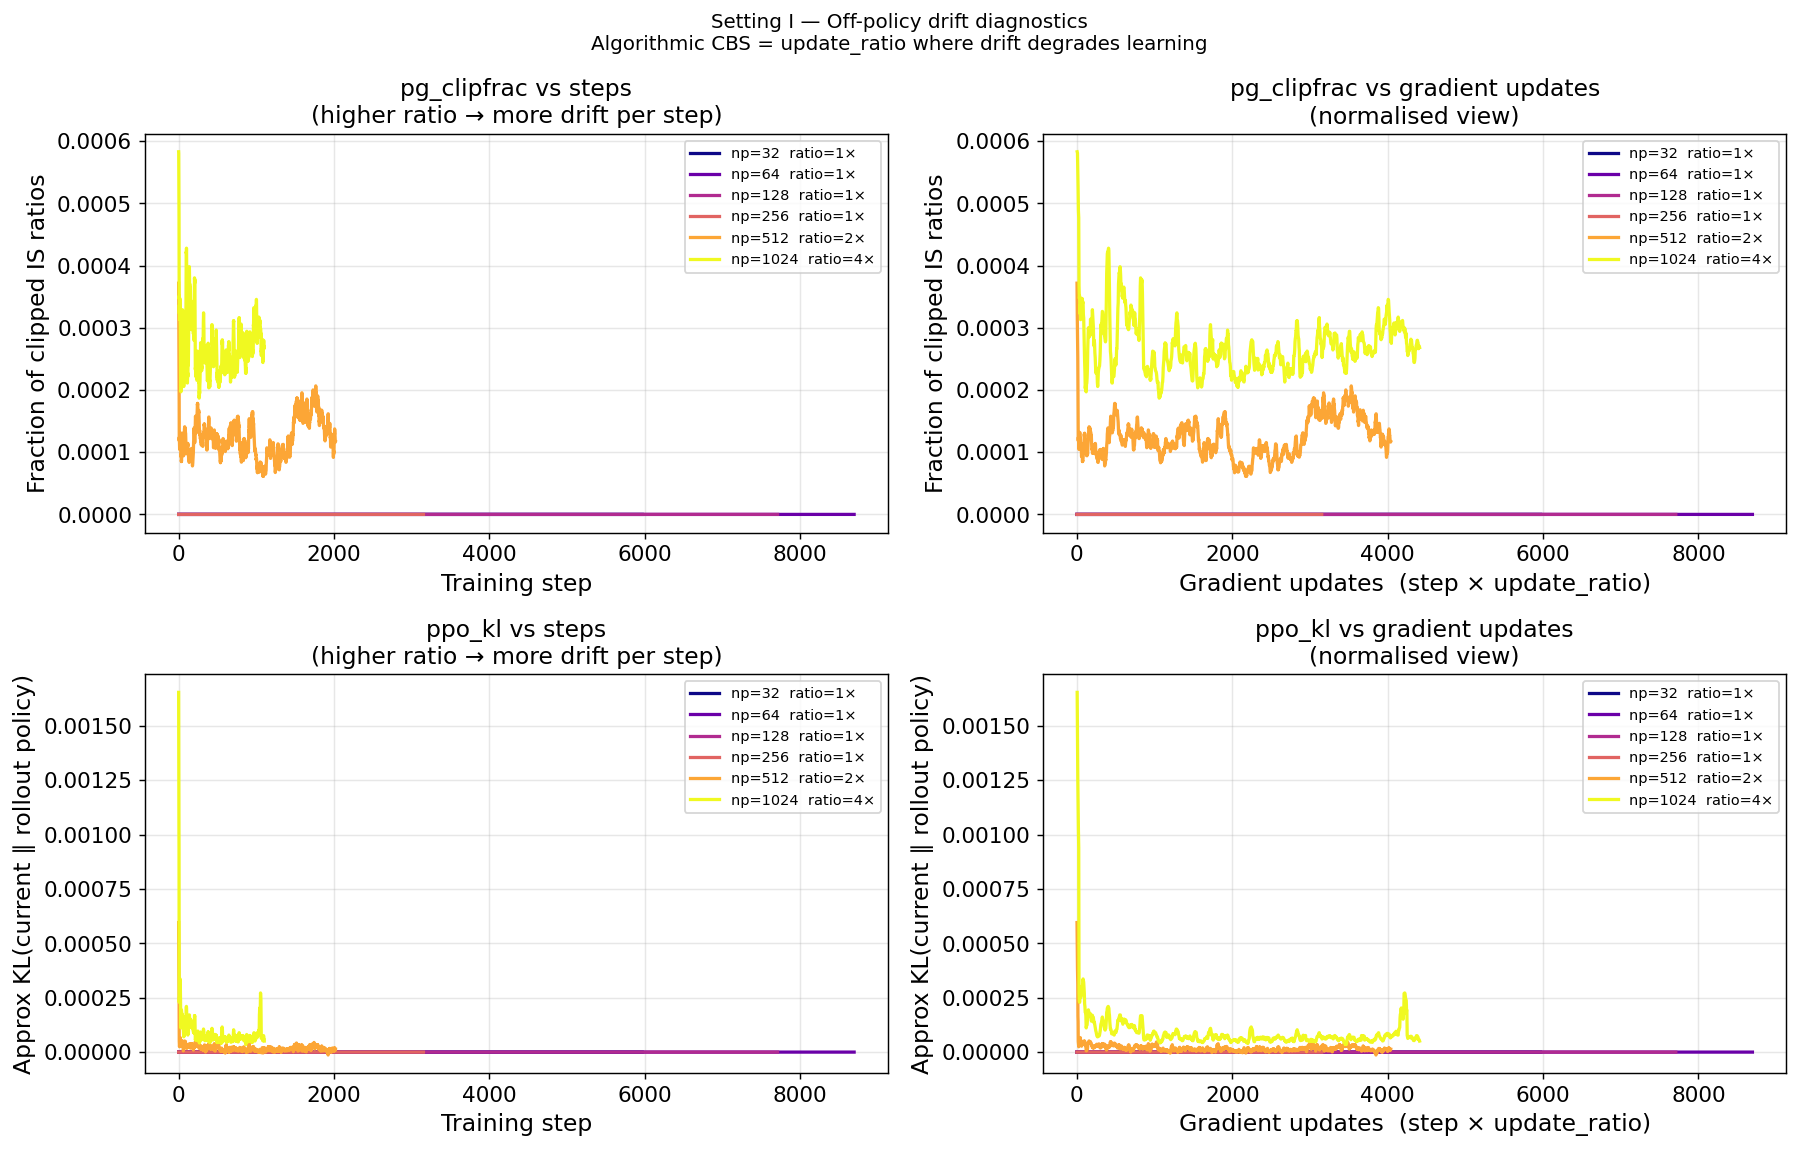

In [43]:
# pg_clipfrac and ppo_kl over training — key off-policy drift indicators
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

for meta in sorted(algo_exps.values(), key=lambda m: m['n_prompts']):
    hist = meta['history']
    c    = ALGO_COLORS[meta['n_prompts']]
    lbl  = f"np={meta['n_prompts']}  ratio={meta['update_ratio']:.0f}×"
    ur   = meta['update_ratio']

    for row, col in enumerate([CLIPFRAC_COL, KL_COL]):
        if col not in hist.columns: continue
        df = hist[[STEP_COL, col]].dropna().sort_values(STEP_COL)
        if df.empty: continue
        # vs training step
        axes[row][0].plot(df[STEP_COL], smooth(df[col], 10), color=c, label=lbl)
        # vs gradient update count = step × update_ratio (normalises for ratio)
        axes[row][1].plot(df[STEP_COL] * ur, smooth(df[col], 10), color=c, label=lbl)

for row, (col_name, ylabel) in enumerate([
    ('pg_clipfrac', 'Fraction of clipped IS ratios'),
    ('ppo_kl',      'Approx KL(current ∥ rollout policy)'),
]):
    axes[row][0].set_xlabel('Training step')
    axes[row][1].set_xlabel('Gradient updates  (step × update_ratio)')
    for ax in axes[row]:
        ax.set_ylabel(ylabel)
        ax.legend(fontsize=8)
        ax.grid(alpha=.3)
    axes[row][0].set_title(f'{col_name} vs steps\n(higher ratio → more drift per step)')
    axes[row][1].set_title(f'{col_name} vs gradient updates\n(normalised view)')

plt.suptitle('Setting I — Off-policy drift diagnostics\n'
             'Algorithmic CBS = update_ratio where drift degrades learning', fontsize=11)
plt.tight_layout()
plt.savefig('fig_I_offpolicy_timeseries.pdf', bbox_inches='tight')
plt.show()

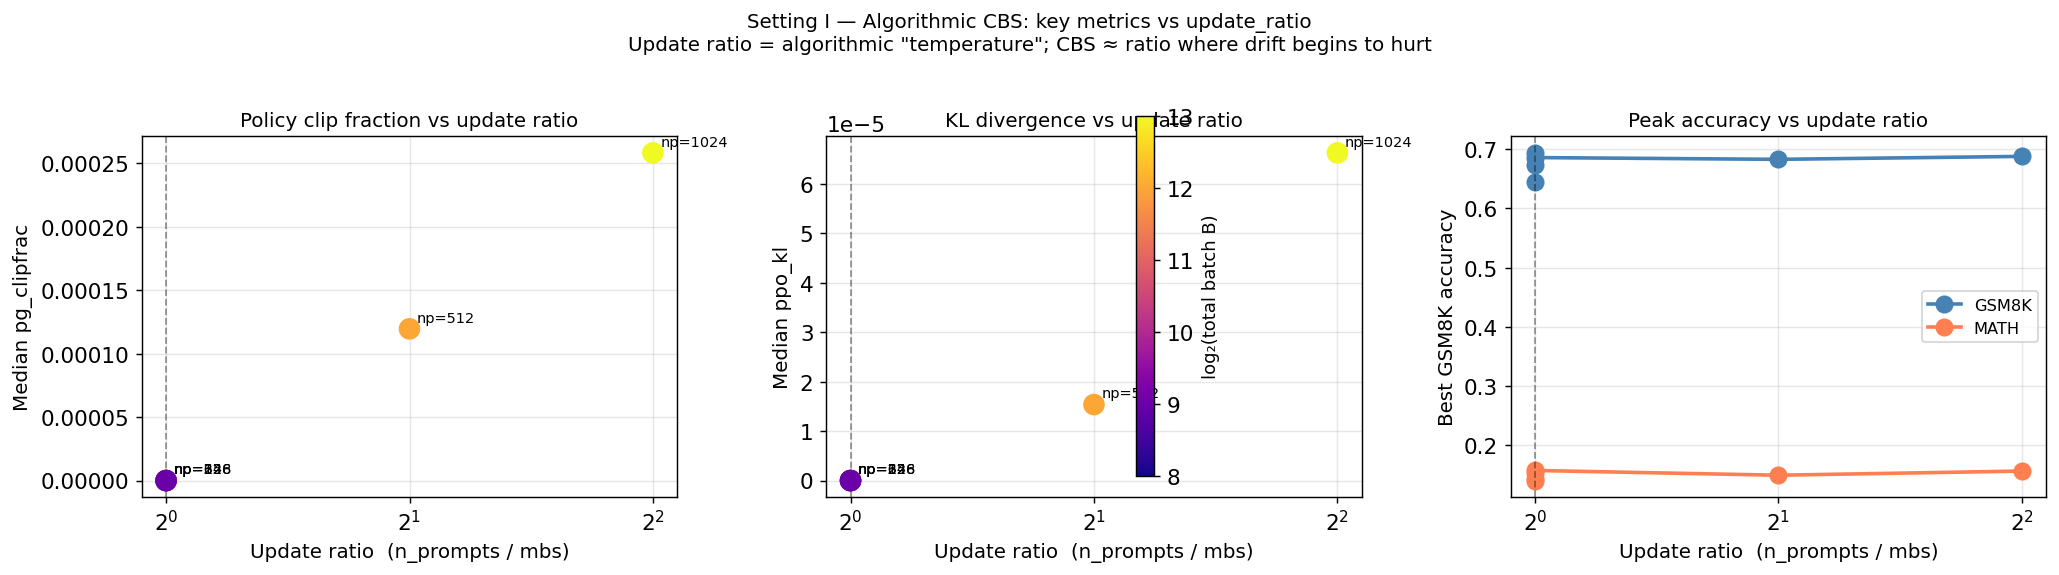


Diagnostic table:
  np    B  update_ratio  med_clipfrac   med_kl  gsm8k_best  math_best
 256 2048           1.0      0.000000 0.000000       0.674   0.143287
  32  256           1.0      0.000000 0.000000       0.645   0.140281
 128 1024           1.0      0.000000 0.000000       0.694   0.153307
  64  512           1.0      0.000000 0.000000       0.686   0.157315
 512 4096           2.0      0.000120 0.000015       0.683   0.149299
1024 8192           4.0      0.000258 0.000066       0.688   0.156313


In [44]:
# The key summary: off-policy metrics and performance vs update_ratio
diag_algo = []
for name, meta in algo_exps.items():
    hist = meta['history']
    def _med(c): return hist[c].dropna().median() if c in hist.columns and not hist[c].dropna().empty else float('nan')
    def _max(c): return hist[c].dropna().max()    if c in hist.columns and not hist[c].dropna().empty else float('nan')
    diag_algo.append({
        'np':          meta['n_prompts'],
        'B':           meta['total_batch'],
        'update_ratio':meta['update_ratio'],
        'med_clipfrac':_med(CLIPFRAC_COL),
        'med_kl':      _med(KL_COL),
        'mean_gradnorm':_med(GRADNORM_COL),
        'gsm8k_best':  _max(GSM8K_COL),
        'math_best':   _max(MATH_COL),
    })
diag_algo = pd.DataFrame(diag_algo).sort_values('update_ratio')

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
c_b = np.log2(diag_algo['B'].clip(lower=1))
sm  = plt.cm.ScalarMappable(cmap='plasma',
                              norm=plt.Normalize(vmin=c_b.min(), vmax=c_b.max()))
sm.set_array([])

for ax, ycol, ylabel, title in [
    (axes[0], 'med_clipfrac',  'Median pg_clipfrac',    'Policy clip fraction vs update ratio'),
    (axes[1], 'med_kl',        'Median ppo_kl',         'KL divergence vs update ratio'),
    (axes[2], 'gsm8k_best',    'Best GSM8K accuracy',   'Peak accuracy vs update ratio'),
]:
    if ycol == 'gsm8k_best':
        for metric, label, col in [('gsm8k_best', 'GSM8K', 'steelblue'),
                                    ('math_best',  'MATH',  'coral')]:
            axes[2].plot(diag_algo['update_ratio'], diag_algo[metric],
                         'o-', color=col, label=label, ms=9, lw=2)
        axes[2].legend(fontsize=9)
    else:
        sc = ax.scatter(diag_algo['update_ratio'], diag_algo[ycol],
                        c=c_b, cmap='plasma', s=120, zorder=5)
        for _, r in diag_algo.iterrows():
            ax.annotate(f"np={int(r['np'])}",
                        (r['update_ratio'], r[ycol]),
                        fontsize=8, xytext=(4, 4), textcoords='offset points')
    ax.axvline(1.0, color='k', ls='--', alpha=.4, lw=1, label='ratio=1 (on-policy)')
    ax.set_xlabel('Update ratio  (n_prompts / mbs)', fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title, fontsize=11)
    ax.set_xscale('log', base=2)
    ax.grid(alpha=.3)

cbar = fig.colorbar(sm, ax=axes[:2], shrink=0.8, pad=0.01)
cbar.set_label('log₂(total batch B)', fontsize=10)

plt.suptitle('Setting I — Algorithmic CBS: key metrics vs update_ratio\n'
             'Update ratio = algorithmic "temperature"; CBS ≈ ratio where drift begins to hurt',
             fontsize=11)
plt.tight_layout()
plt.savefig('fig_I_vs_update_ratio.pdf', bbox_inches='tight')
plt.show()

print('\nDiagnostic table:')
print(diag_algo[['np','B','update_ratio','med_clipfrac','med_kl','gsm8k_best','math_best']].to_string(index=False))

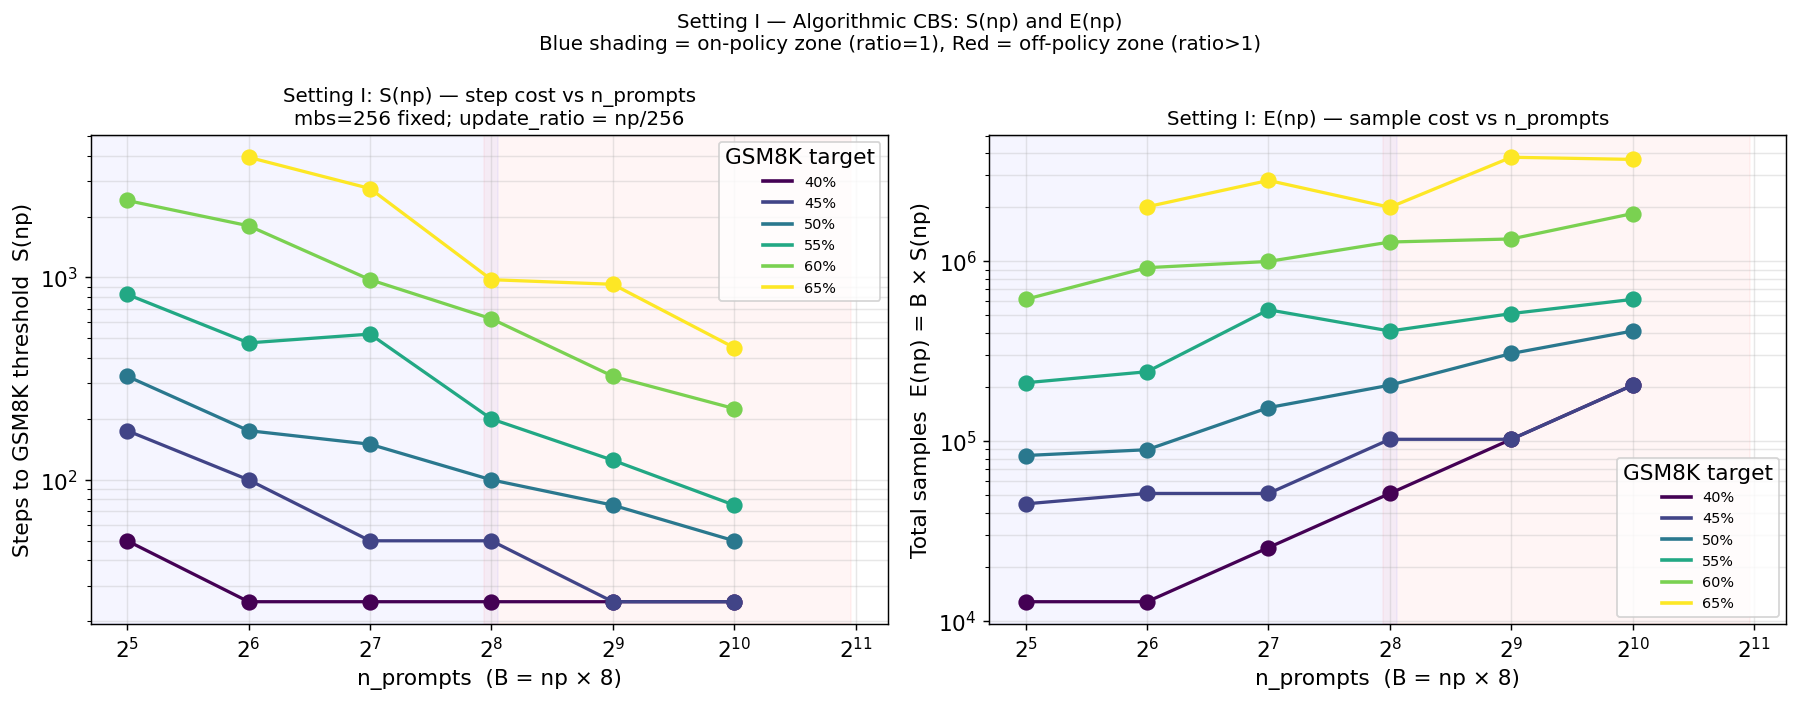

In [45]:
# Steps-to-threshold and sample cost vs n_prompts (algorithmic setting)
def steps_to_threshold(hist, col, thr):
    df = hist[[STEP_COL, col]].dropna().sort_values(STEP_COL)
    above = df[df[col] >= thr]
    return float(above[STEP_COL].iloc[0]) if len(above) else None

def compute_sb(exps, col, thresholds):
    rows = []
    for name, meta in exps.items():
        hist = meta['history']
        if col not in hist.columns: continue
        for thr in thresholds:
            s = steps_to_threshold(hist, col, thr)
            rows.append({
                'name': name, 'n_prompts': meta['n_prompts'],
                'B':    meta['total_batch'],
                'mbs':  meta['mbs_eff'],
                'update_ratio': meta['update_ratio'],
                'clip_ratio':   meta['clip_ratio'],
                'threshold': thr,
                'S_B': s,
                'E_B': s * meta['total_batch'] if s else None,
            })
    return pd.DataFrame(rows)

gsm_thrs  = [0.40, 0.45, 0.50, 0.55, 0.60, 0.65]
math_thrs = [0.06, 0.08, 0.10, 0.12, 0.14]
thr_colors = {t: plt.cm.viridis(i / max(len(gsm_thrs)-1, 1)) for i, t in enumerate(gsm_thrs)}

sb_algo = compute_sb(algo_exps, GSM8K_COL, gsm_thrs)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

for thr in gsm_thrs:
    sub = sb_algo[(sb_algo['threshold']==thr) & sb_algo['S_B'].notna()].sort_values('n_prompts')
    if sub.empty: continue
    c = thr_colors[thr]
    axes[0].plot(sub['n_prompts'], sub['S_B'], 'o-', color=c, ms=8, label=f'{thr:.0%}')
    if sub['E_B'].notna().any():
        axes[1].plot(sub['n_prompts'], sub['E_B'], 'o-', color=c, ms=8, label=f'{thr:.0%}')

# Shade background by regime
for ax in axes:
    ax.axvspan(0, ALGO_MBS + 10, alpha=.04, color='blue',
               label='ratio=1 zone (np≤256)')
    ax.axvspan(ALGO_MBS - 10, 2000, alpha=.04, color='red',
               label='ratio>1 zone (np>256)')

for ax, ylabel, title in [
    (axes[0], 'Steps to GSM8K threshold  S(np)',
     'Setting I: S(np) — step cost vs n_prompts\nmbs=256 fixed; update_ratio = np/256'),
    (axes[1], 'Total samples  E(np) = B × S(np)',
     'Setting I: E(np) — sample cost vs n_prompts'),
]:
    ax.set_xscale('log', base=2)
    ax.set_yscale('log')
    ax.set_xlabel('n_prompts  (B = np × 8)', fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(title, fontsize=11)
    ax.legend(handles=[Line2D([0],[0], color=thr_colors[t], lw=2, label=f'{t:.0%}')
                        for t in gsm_thrs],
              title='GSM8K target', fontsize=8)
    ax.grid(alpha=.3, which='both')

plt.suptitle('Setting I — Algorithmic CBS: S(np) and E(np)\n'
             'Blue shading = on-policy zone (ratio=1), Red = off-policy zone (ratio>1)',
             fontsize=11)
plt.tight_layout()
plt.savefig('fig_I_sb_eb.pdf', bbox_inches='tight')
plt.show()

---
## Setting II — Statistical CBS

**Design:** `mbs = n_prompts` (always on-policy), varying `n_prompts`, `n_rollouts=8`, `cr=0.2`, `ep=1`.

**Key mechanism:** With `update_ratio = 1`, there is exactly **one gradient step per rollout batch**. The only factor limiting batch-size scaling is **gradient noise** `B_noise`. The McCandlish model predicts:

$$S(B) = S_{\min} \cdot \left(1 + \frac{B_{\text{noise}}}{B}\right)$$

where `B_noise` = the **statistical critical batch size** (CBS).

**Diagnostic questions:**
- What is `B_noise` (from gradient noise estimates or McCandlish fit)?
- Does `S(B)` follow the McCandlish model?
- What is `E(B) = B × S(B)` and where is its minimum?

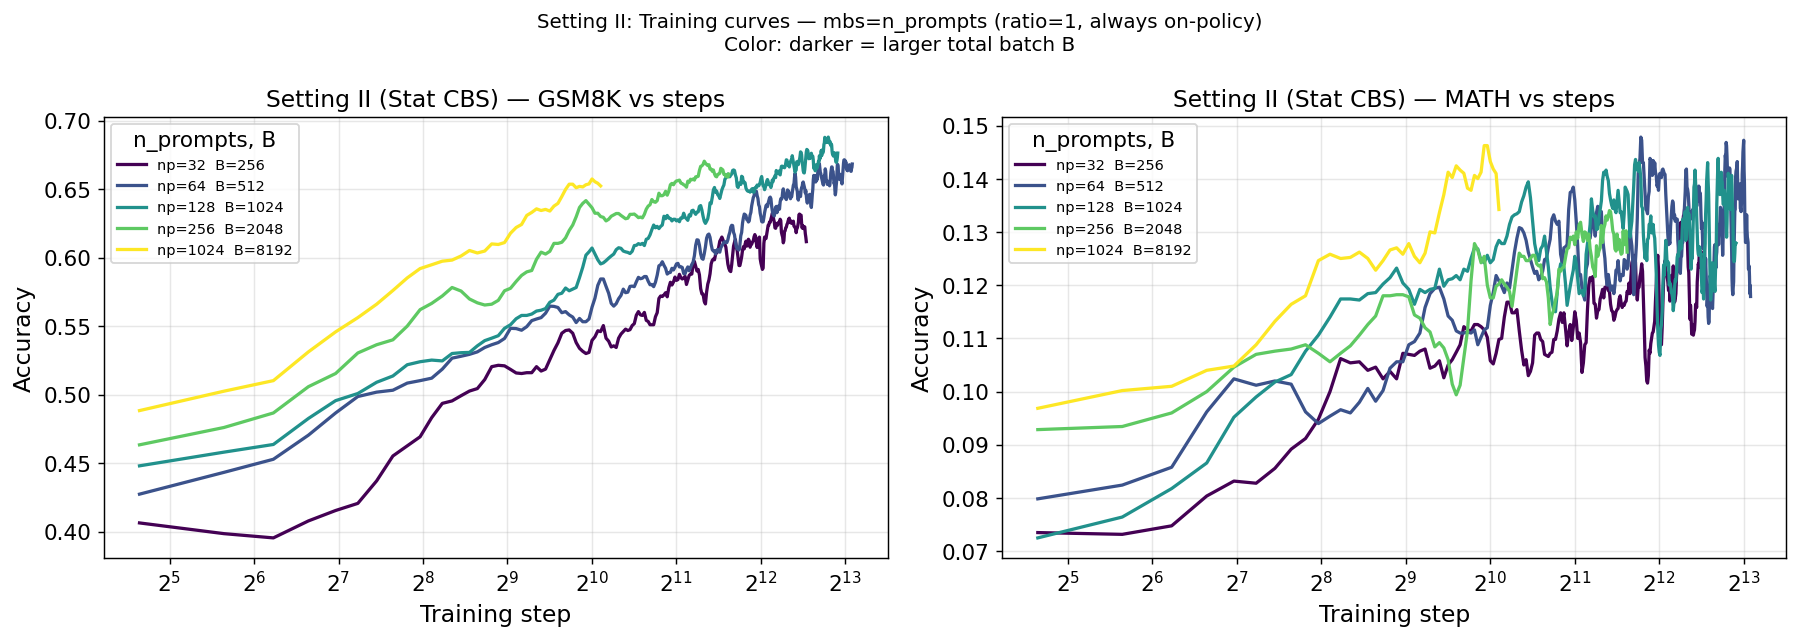

In [46]:
B_vals_stat  = sorted({m['total_batch'] for m in stat_exps.values()})
STAT_COLORS  = {B: plt.cm.viridis(i / max(len(B_vals_stat)-1, 1))
                for i, B in enumerate(B_vals_stat)}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for meta in sorted(stat_exps.values(), key=lambda m: m['total_batch']):
    hist = meta['history']
    B    = meta['total_batch']
    c    = STAT_COLORS[B]
    lbl  = f"np={meta['n_prompts']}  B={B}"
    for ax, col in [(axes[0], GSM8K_COL), (axes[1], MATH_COL)]:
        df = hist[[STEP_COL, col]].dropna().sort_values(STEP_COL)
        if df.empty: continue
        ax.plot(df[STEP_COL], smooth(df[col]), color=c, label=lbl)
        ax.set_xscale('log', base=2)

for ax, title in zip(axes, ['GSM8K', 'MATH']):
    ax.set_xlabel('Training step')
    ax.set_ylabel('Accuracy')
    ax.set_title(f'Setting II (Stat CBS) — {title} vs steps')
    ax.legend(fontsize=8, title='n_prompts, B')
    ax.grid(alpha=.3)

plt.suptitle('Setting II: Training curves — mbs=n_prompts (ratio=1, always on-policy)\n'
             'Color: darker = larger total batch B', fontsize=11)
plt.tight_layout()
plt.savefig('fig_II_accuracy_vs_steps.pdf', bbox_inches='tight')
plt.show()

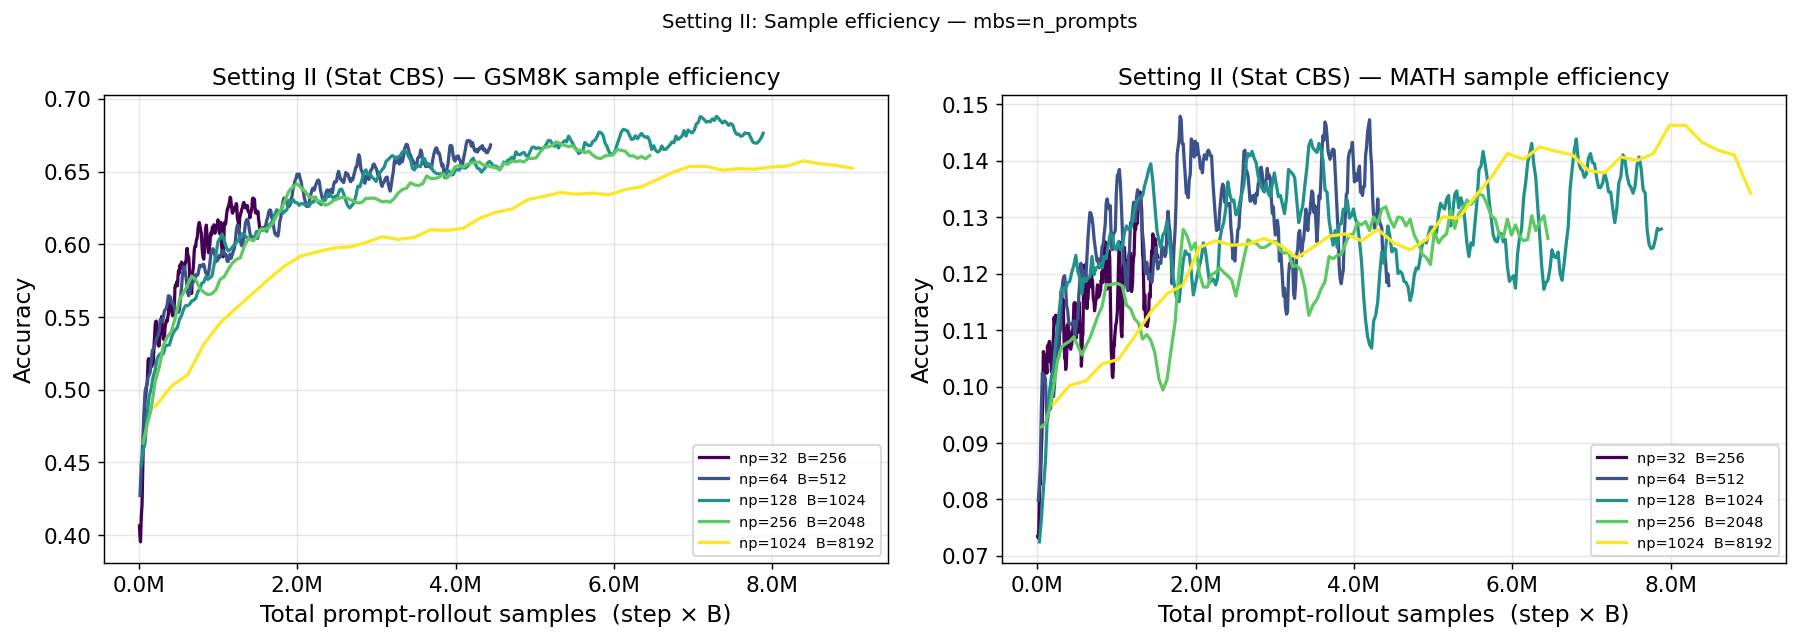

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for meta in sorted(stat_exps.values(), key=lambda m: m['total_batch']):
    hist = meta['history']
    B    = meta['total_batch']
    c    = STAT_COLORS[B]
    lbl  = f"np={meta['n_prompts']}  B={B}"
    for ax, col in [(axes[0], GSM8K_COL), (axes[1], MATH_COL)]:
        df = hist[[STEP_COL, col]].dropna().sort_values(STEP_COL)
        if df.empty: continue
        ax.plot(df[STEP_COL] * B, smooth(df[col]), color=c, label=lbl)

for ax, title in zip(axes, ['GSM8K', 'MATH']):
    ax.set_xlabel('Total prompt-rollout samples  (step × B)')
    ax.set_ylabel('Accuracy')
    ax.set_title(f'Setting II (Stat CBS) — {title} sample efficiency')
    ax.legend(fontsize=8)
    ax.grid(alpha=.3)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

plt.suptitle('Setting II: Sample efficiency — mbs=n_prompts', fontsize=11)
plt.tight_layout()
plt.savefig('fig_II_accuracy_vs_samples.pdf', bbox_inches='tight')
plt.show()

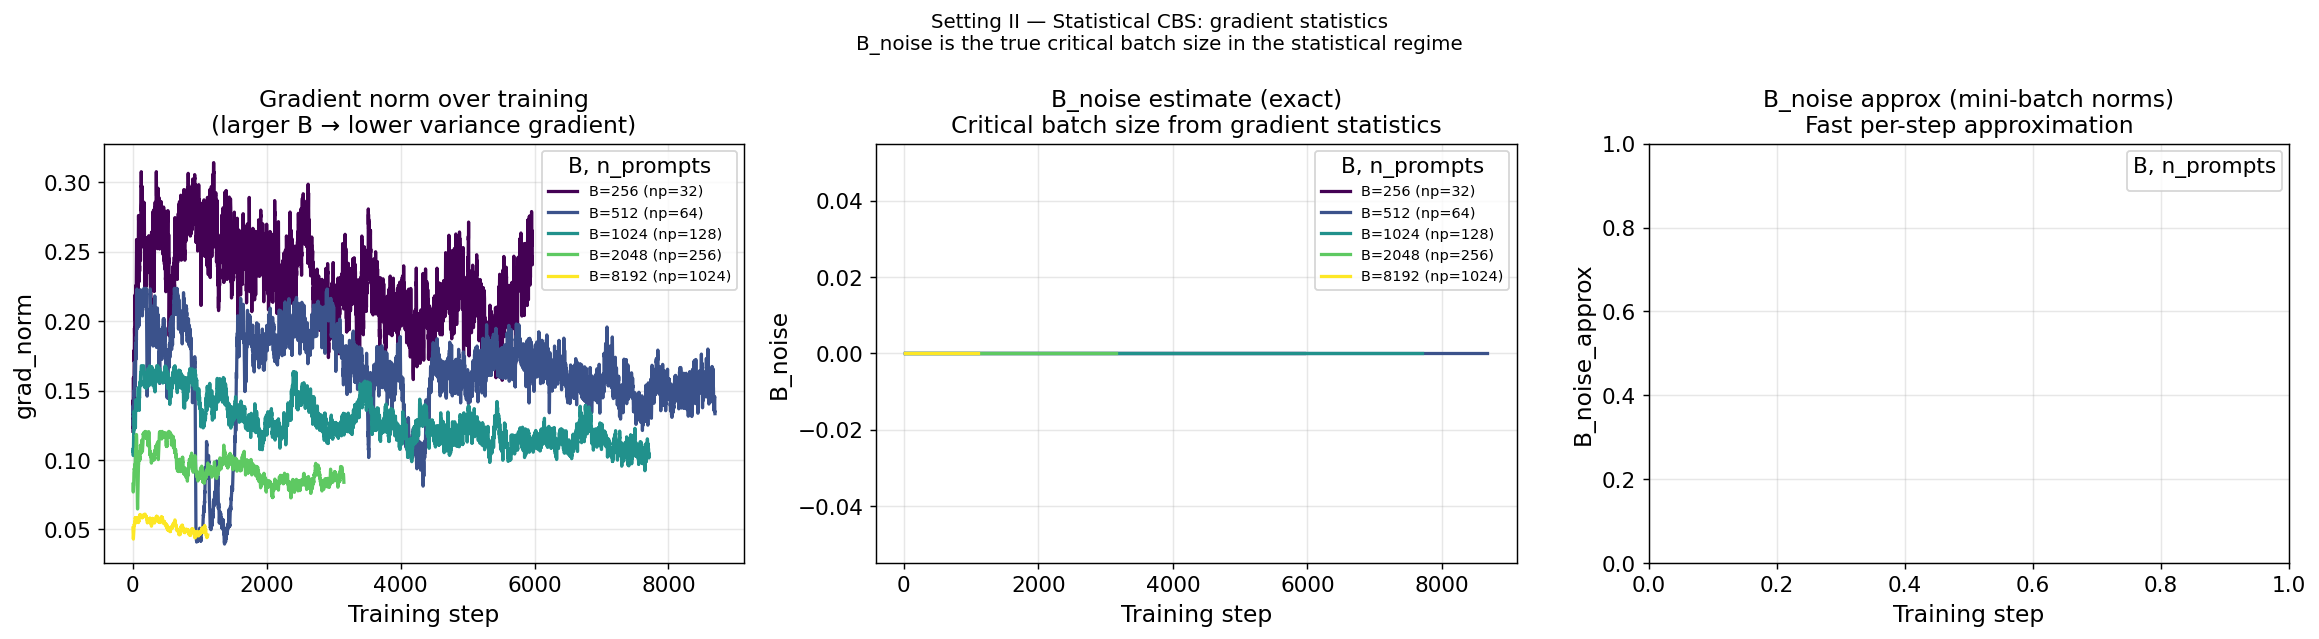

In [48]:
# Gradient norm and B_noise over training
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
has_noise = False

for meta in sorted(stat_exps.values(), key=lambda m: m['total_batch']):
    hist = meta['history']
    B    = meta['total_batch']
    c    = STAT_COLORS[B]
    lbl  = f"B={B} (np={meta['n_prompts']})"

    for ax, col in [(axes[0], GRADNORM_COL), (axes[1], BNOISE_COL), (axes[2], BNOISE_APX)]:
        if col not in hist.columns: continue
        df = hist[[STEP_COL, col]].dropna().sort_values(STEP_COL)
        if df.empty: continue
        vals = df[col].clip(upper=df[col].quantile(.95))
        ax.plot(df[STEP_COL], smooth(vals, 7), color=c, label=lbl)
        if col in (BNOISE_COL, BNOISE_APX):
            has_noise = True

for ax, ylabel, title in [
    (axes[0], 'grad_norm',     'Gradient norm over training\n(larger B → lower variance gradient)'),
    (axes[1], 'B_noise',       'B_noise estimate (exact)\nCritical batch size from gradient statistics'),
    (axes[2], 'B_noise_approx','B_noise approx (mini-batch norms)\nFast per-step approximation'),
]:
    ax.set_xlabel('Training step')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(fontsize=8, title='B, n_prompts')
    ax.grid(alpha=.3)

if not has_noise:
    print('No B_noise data logged. Enable grad_noise_measure_freq in training config.')
    plt.close()
else:
    plt.suptitle('Setting II — Statistical CBS: gradient statistics\n'
                 'B_noise is the true critical batch size in the statistical regime', fontsize=11)
    plt.tight_layout()
    plt.savefig('fig_II_grad_stats.pdf', bbox_inches='tight')
    plt.show()

In [49]:
def mccandlish_S(B, S_min, B_noise): return S_min * (1 + B_noise / B)
def mccandlish_E(B, E_min, B_noise): return E_min * (1 + B / B_noise)

def fit_mccandlish(sb_df, thr):
    sub = sb_df[(sb_df['threshold'] == thr) & sb_df['S_B'].notna()]
    if len(sub) < 3: return None
    B, S = sub['B'].values.astype(float), sub['S_B'].values.astype(float)
    try:
        popt, _ = curve_fit(mccandlish_S, B, S,
                            p0=[S.min(), float(B[len(B)//2])],
                            bounds=([0,0],[np.inf,np.inf]), maxfev=10000)
        S_pred = mccandlish_S(B, *popt)
        ss_res = np.sum((S - S_pred)**2)
        ss_tot = np.sum((S - S.mean())**2)
        return dict(S_min=popt[0], B_noise=popt[1],
                    R2=(1-ss_res/ss_tot if ss_tot>0 else 0),
                    B_arr=B, S_arr=S)
    except Exception:
        return None

sb_stat  = compute_sb(stat_exps, GSM8K_COL, gsm_thrs)
stat_fits = {}
for thr in gsm_thrs:
    f = fit_mccandlish(sb_stat, thr)
    if f:
        stat_fits[thr] = f
        print(f'  thr={thr:.0%}  B* = {f["B_noise"]:.0f}  S_min = {f["S_min"]:.1f}  R² = {f["R2"]:.3f}')

if not stat_fits:
    print('Not enough data above any threshold for McCandlish fit.')

  thr=40%  B* = 325  S_min = 20.2  R² = 0.795
  thr=45%  B* = 1096  S_min = 32.3  R² = 0.960
  thr=50%  B* = 914  S_min = 69.9  R² = 0.981
  thr=55%  B* = 836  S_min = 196.0  R² = 0.867
  thr=60%  B* = 1364  S_min = 404.2  R² = 0.949
  thr=65%  B* = 3541  S_min = 512.5  R² = 0.937


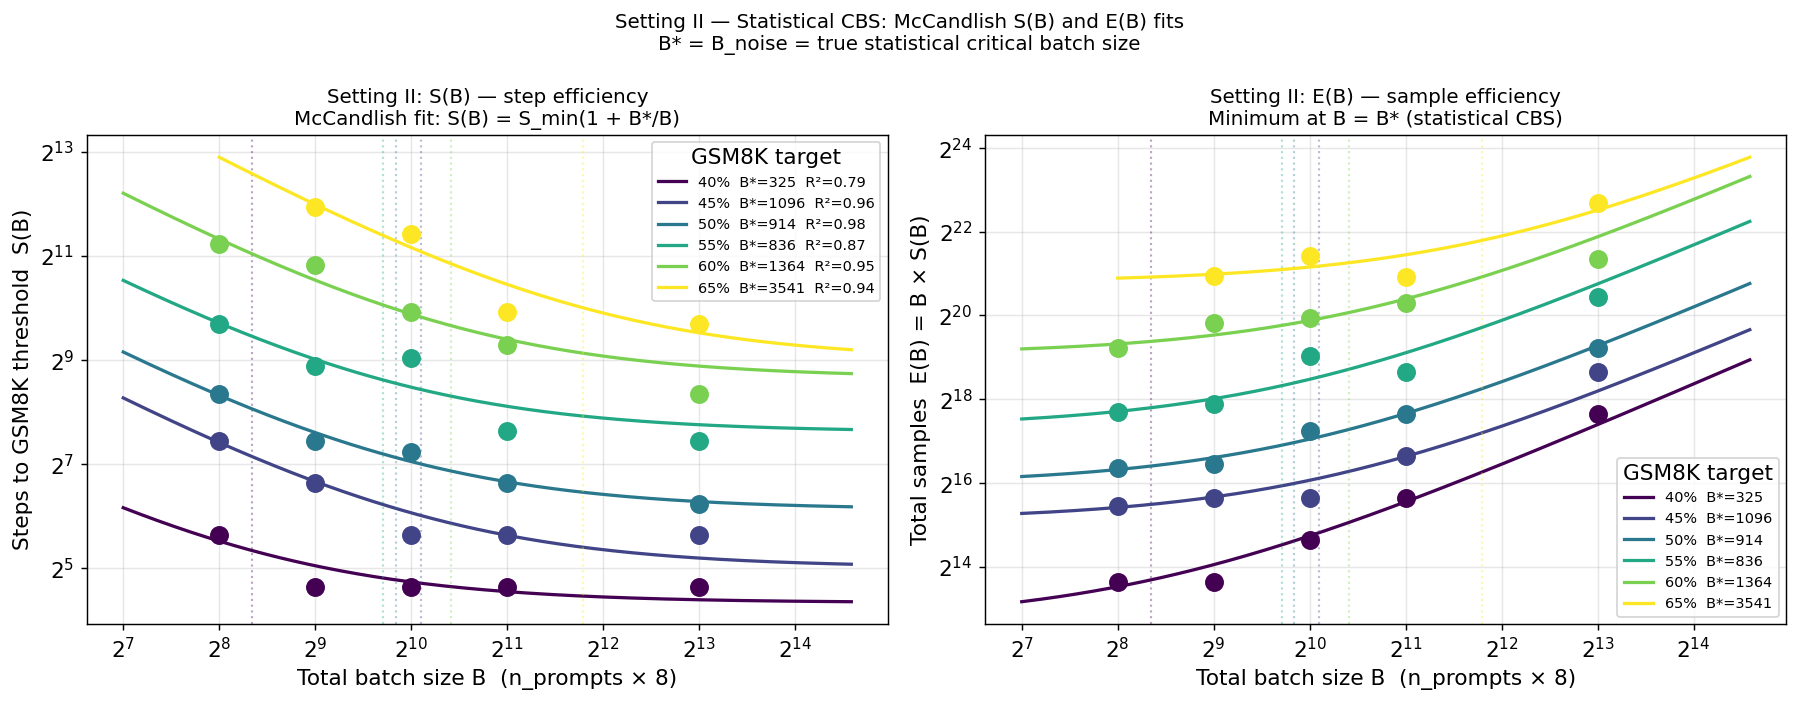

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

for thr in gsm_thrs:
    sub = sb_stat[(sb_stat['threshold'] == thr) & sb_stat['S_B'].notna()].sort_values('B')
    if sub.empty: continue
    c = thr_colors[thr]
    axes[0].scatter(sub['B'], sub['S_B'], color=c, s=90, zorder=5)
    axes[1].scatter(sub['B'], sub['E_B'], color=c, s=90, zorder=5)

    if thr in stat_fits:
        f     = stat_fits[thr]
        B_min = max(sub['B'].min() * 0.5, 50)
        B_max = sub['B'].max() * 3
        B_p   = np.geomspace(B_min, B_max, 300)
        axes[0].plot(B_p, mccandlish_S(B_p, f['S_min'], f['B_noise']),
                     color=c, label=f"{thr:.0%}  B*={f['B_noise']:.0f}  R²={f['R2']:.2f}")
        axes[0].axvline(f['B_noise'], color=c, ls=':', alpha=.35, lw=1.2)
        E_min = f['S_min'] * f['B_noise']
        axes[1].plot(B_p, mccandlish_E(B_p, E_min, f['B_noise']),
                     color=c, label=f"{thr:.0%}  B*={f['B_noise']:.0f}")
        axes[1].axvline(f['B_noise'], color=c, ls=':', alpha=.35, lw=1.2)
    else:
        axes[0].scatter([], [], color=c, label=f'{thr:.0%}  (no fit)')
        axes[1].scatter([], [], color=c, label=f'{thr:.0%}')

for ax, ylabel, title in [
    (axes[0], 'Steps to GSM8K threshold  S(B)',
     'Setting II: S(B) — step efficiency\nMcCandlish fit: S(B) = S_min(1 + B*/B)'),
    (axes[1], 'Total samples  E(B) = B × S(B)',
     'Setting II: E(B) — sample efficiency\nMinimum at B = B* (statistical CBS)'),
]:
    ax.set_xscale('log', base=2)
    ax.set_yscale('log', base=2)
    ax.set_xlabel('Total batch size B  (n_prompts × 8)', fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=8, title='GSM8K target')
    ax.grid(alpha=.3, which='both')

plt.suptitle('Setting II — Statistical CBS: McCandlish S(B) and E(B) fits\n'
             'B* = B_noise = true statistical critical batch size',
             fontsize=11)
plt.tight_layout()
plt.savefig('fig_II_sb_eb.pdf', bbox_inches='tight')
plt.show()

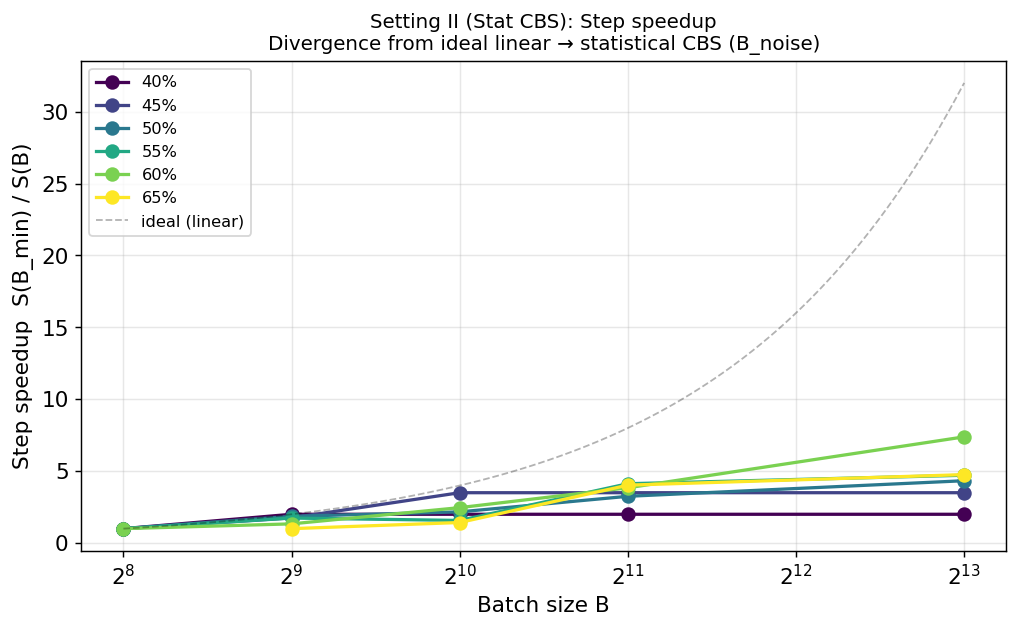

In [51]:
# Step speedup: S(B_min) / S(B) — how much faster is large B vs smallest B?
fig, ax = plt.subplots(figsize=(8, 5))

B_ref = None
for thr in gsm_thrs:
    sub = sb_stat[(sb_stat['threshold'] == thr) & sb_stat['S_B'].notna()].sort_values('B')
    if len(sub) < 2: continue
    B, S = sub['B'].values.astype(float), sub['S_B'].values.astype(float)
    B_ref = B_ref or B.min()
    ax.plot(B, S[0] / S, 'o-', color=thr_colors[thr], ms=7,
            label=f'{thr:.0%}')

if B_ref:
    B_range = np.geomspace(sb_stat['B'].dropna().min(), sb_stat['B'].dropna().max(), 100)
    ax.plot(B_range, B_range / B_ref, 'k--', alpha=.3, lw=1, label='ideal (linear)')

ax.set_xscale('log', base=2)
ax.set_xlabel('Batch size B', fontsize=12)
ax.set_ylabel('Step speedup  S(B_min) / S(B)', fontsize=12)
ax.set_title('Setting II (Stat CBS): Step speedup\n'
             'Divergence from ideal linear → statistical CBS (B_noise)', fontsize=11)
ax.legend(fontsize=9)
ax.grid(alpha=.3)
plt.tight_layout()
plt.savefig('fig_II_speedup.pdf', bbox_inches='tight')
plt.show()

---
## Setting III — Clip Ratio Ablation

**Design:** Same base config (fixed mbs=256, varying n_prompts), but vary `clip_ratio` ∈ {0.0, 0.2, 1.0}.

- `cr = 0.2`: Standard PPO clipping — IS ratios clipped to [0.8, 1.2]
- `cr = 0.0`: **No clipping** — pure unclipped REINFORCE-style surrogate  
- `cr = 1.0`: **Loose clipping** — IS ratios clipped to [0.0, 2.0] (nearly unclipped)

**Diagnostic questions:**
- Does removing the clip (`cr=0.0`) help or hurt learning speed?
- Does `pg_clipfrac` drop to zero with `cr=0.0` (as expected)?
- Is clipping necessary as a safety constraint, or does it slow convergence?
- Does the effect of clip ratio interact with the update_ratio (algorithmic vs statistical)?

Clip ratios found: [0.0]
n_prompts with non-standard cr: [1024]


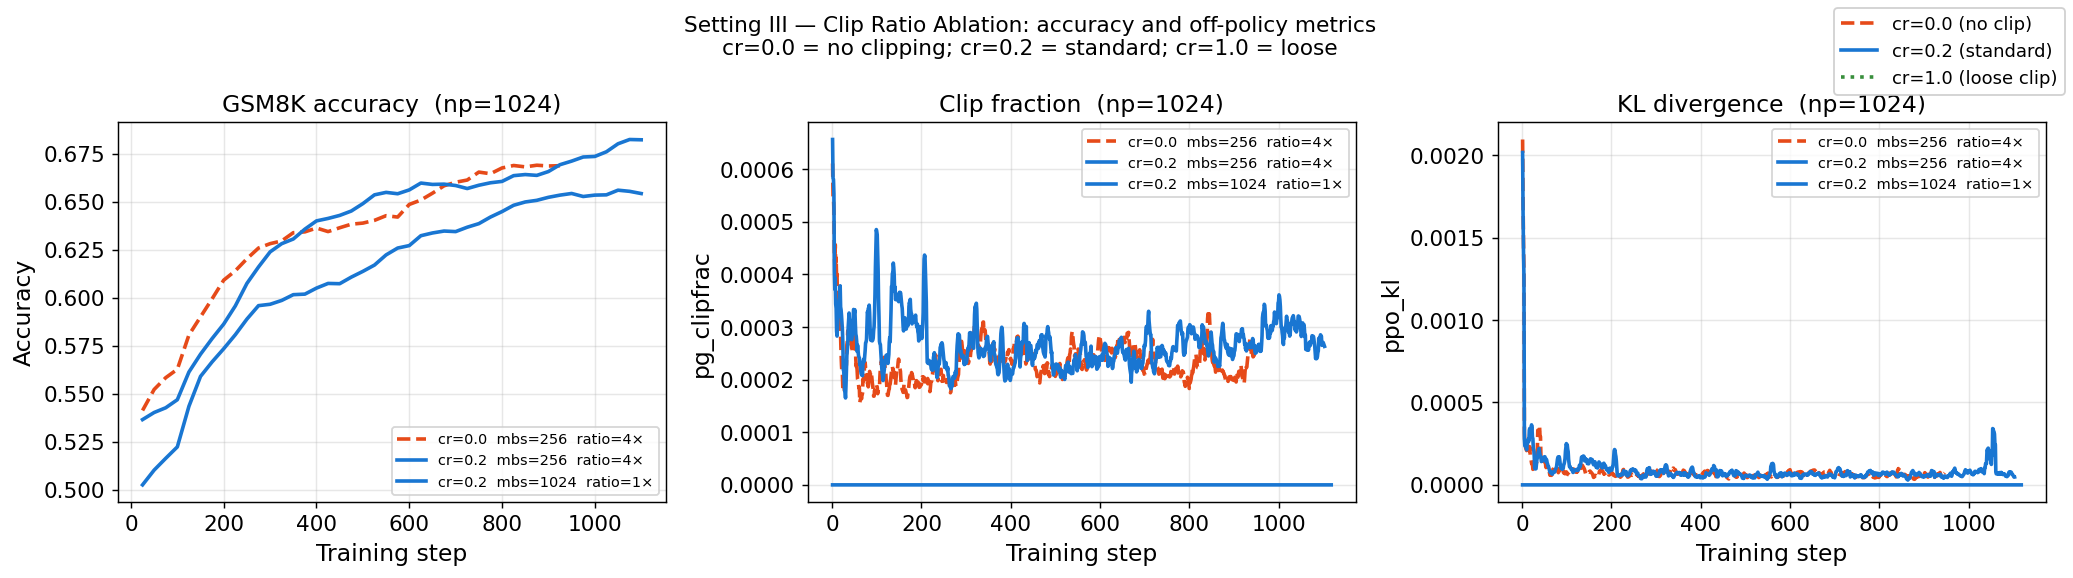

In [52]:
CR_COLORS = {0.0: '#E64A19', 0.2: '#1976D2', 1.0: '#388E3C'}
CR_LS     = {0.0: '--',       0.2: '-',         1.0: ':'}

np_with_ablation = sorted({m['n_prompts'] for m in clip_exps.values()})
print(f'Clip ratios found: {sorted({m["clip_ratio"] for m in clip_exps.values()})}')
print(f'n_prompts with non-standard cr: {np_with_ablation}')

if not np_with_ablation:
    print('No clip ablation data found.')
else:
    n_rows = len(np_with_ablation)
    fig, axes = plt.subplots(n_rows, 3, figsize=(16, 4.5 * n_rows), squeeze=False)

    for row_idx, np_val in enumerate(np_with_ablation):
        # All ep=1 runs at this n_prompts (all clip ratios)
        runs_here = sorted(
            [(k, v) for k, v in experiments.items()
             if v['n_prompts'] == np_val and v['ppo_epochs'] == 1],
            key=lambda x: x[1]['clip_ratio']
        )

        for name, meta in runs_here:
            hist = meta['history']
            cr   = meta['clip_ratio']
            c    = CR_COLORS.get(cr, 'purple')
            ls   = CR_LS.get(cr, '-.')
            lbl  = f"cr={cr}  mbs={meta['mbs_eff']}  ratio={meta['update_ratio']:.0f}×"

            for ax_idx, col in enumerate([GSM8K_COL, CLIPFRAC_COL, KL_COL]):
                df = hist[[STEP_COL, col]].dropna().sort_values(STEP_COL)
                if df.empty: continue
                axes[row_idx][ax_idx].plot(df[STEP_COL], smooth(df[col], 7),
                                           color=c, ls=ls, label=lbl, lw=2)

        for ax_idx, (ylabel, title) in enumerate([
            ('Accuracy',      f'GSM8K accuracy  (np={np_val})'),
            ('pg_clipfrac',   f'Clip fraction  (np={np_val})'),
            ('ppo_kl',        f'KL divergence  (np={np_val})'),
        ]):
            axes[row_idx][ax_idx].set_xlabel('Training step')
            axes[row_idx][ax_idx].set_ylabel(ylabel)
            axes[row_idx][ax_idx].set_title(title)
            axes[row_idx][ax_idx].legend(fontsize=8)
            axes[row_idx][ax_idx].grid(alpha=.3)

    legend_handles = [
        Line2D([0],[0], color=CR_COLORS[0.0], ls='--', lw=2, label='cr=0.0 (no clip)'),
        Line2D([0],[0], color=CR_COLORS[0.2], ls='-',  lw=2, label='cr=0.2 (standard)'),
        Line2D([0],[0], color=CR_COLORS[1.0], ls=':',  lw=2, label='cr=1.0 (loose clip)'),
    ]
    fig.legend(handles=legend_handles, loc='upper right', fontsize=10, framealpha=.9)
    plt.suptitle('Setting III — Clip Ratio Ablation: accuracy and off-policy metrics\n'
                 'cr=0.0 = no clipping; cr=0.2 = standard; cr=1.0 = loose', fontsize=12)
    plt.tight_layout()
    plt.savefig('fig_III_clip_ablation_panels.pdf', bbox_inches='tight')
    plt.show()

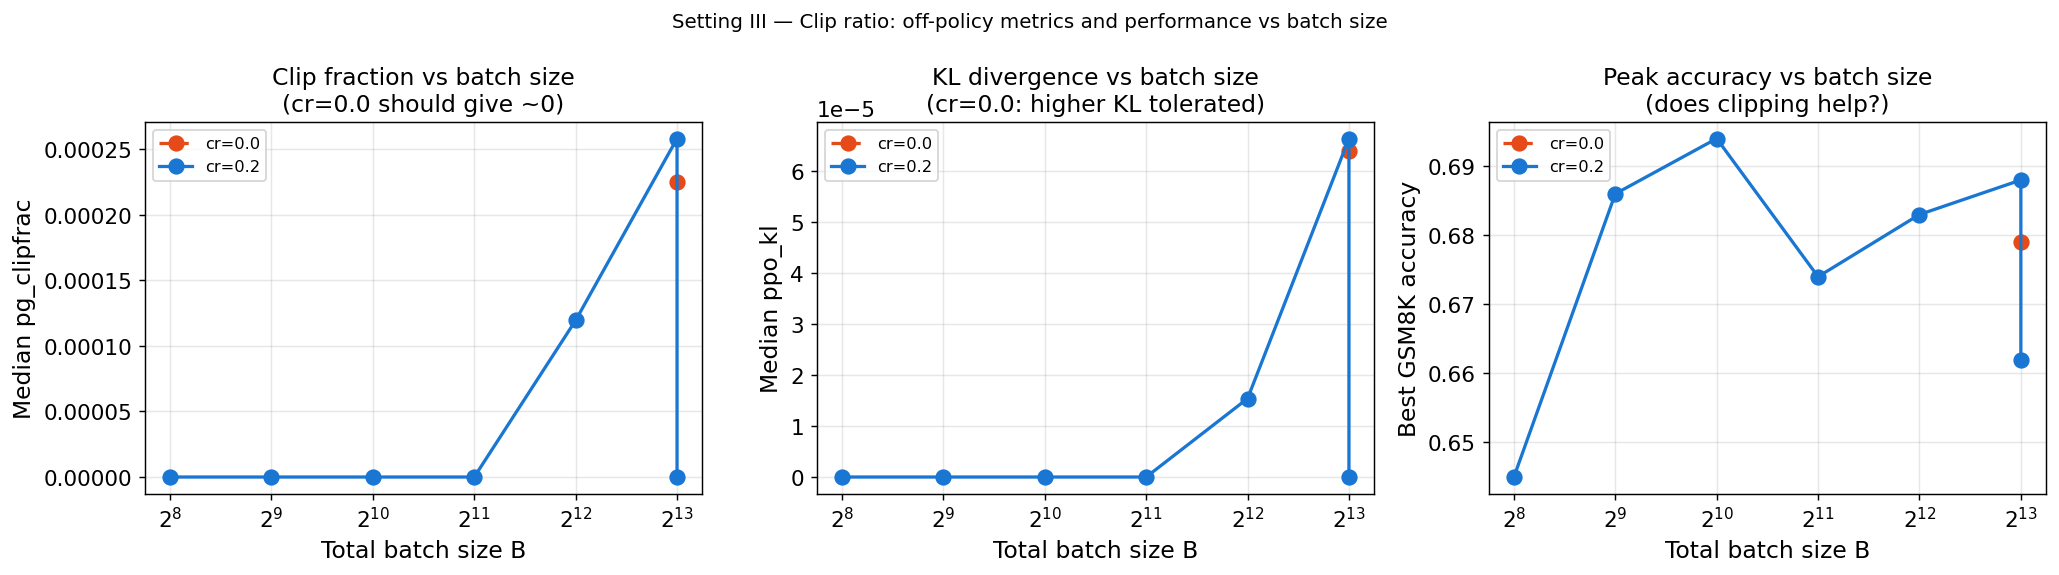

In [53]:
# Summary: clip-ratio effect on metrics across all batch sizes
cr_summary = []
for name, meta in experiments.items():
    hist = meta['history']
    def _med(c): return hist[c].dropna().median() if c in hist.columns and not hist[c].dropna().empty else float('nan')
    def _max(c): return hist[c].dropna().max()    if c in hist.columns and not hist[c].dropna().empty else float('nan')
    cr_summary.append({
        'np':    meta['n_prompts'],
        'B':     meta['total_batch'],
        'cr':    meta['clip_ratio'],
        'ur':    meta['update_ratio'],
        'med_cf': _med(CLIPFRAC_COL),
        'med_kl': _med(KL_COL),
        'best_gsm': _max(GSM8K_COL),
        'best_math': _max(MATH_COL),
    })
cr_df = pd.DataFrame(cr_summary)

if cr_df['cr'].nunique() <= 1:
    print('Only one clip ratio found — run clip ablation experiments to populate this section.')
else:
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

    for cr_val, grp in cr_df.groupby('cr'):
        grp = grp.sort_values('B')
        c   = CR_COLORS.get(cr_val, 'grey')
        ls  = CR_LS.get(cr_val, '-.')
        lbl = f'cr={cr_val}'
        valid_cf = grp.dropna(subset=['med_cf'])
        valid_gsm = grp.dropna(subset=['best_gsm'])

        if not valid_cf.empty:
            axes[0].plot(valid_cf['B'], valid_cf['med_cf'],   'o-', color=c, ls=ls, label=lbl, ms=8)
            axes[1].plot(valid_cf['B'], valid_cf['med_kl'],   'o-', color=c, ls=ls, label=lbl, ms=8)
        if not valid_gsm.empty:
            axes[2].plot(valid_gsm['B'], valid_gsm['best_gsm'], 'o-', color=c, ls=ls, label=lbl, ms=8)

    for ax, ylabel, title in [
        (axes[0], 'Median pg_clipfrac', 'Clip fraction vs batch size\n(cr=0.0 should give ~0)'),
        (axes[1], 'Median ppo_kl',      'KL divergence vs batch size\n(cr=0.0: higher KL tolerated)'),
        (axes[2], 'Best GSM8K accuracy','Peak accuracy vs batch size\n(does clipping help?)'),
    ]:
        ax.set_xscale('log', base=2)
        ax.set_xlabel('Total batch size B')
        ax.set_ylabel(ylabel)
        ax.set_title(title)
        ax.legend(fontsize=9)
        ax.grid(alpha=.3)

    plt.suptitle('Setting III — Clip ratio: off-policy metrics and performance vs batch size',
                 fontsize=11)
    plt.tight_layout()
    plt.savefig('fig_III_clip_vs_B.pdf', bbox_inches='tight')
    plt.show()

---
## Cross-Setting Comparison

Having analyzed each setting in isolation, we now compare them directly:

1. **Regime map** — which experiments fall in which regime
2. **S(B) and E(B) overlaid** — statistical vs algorithmic scaling curves
3. **Controlled comparison** — same B, different settings (if available)

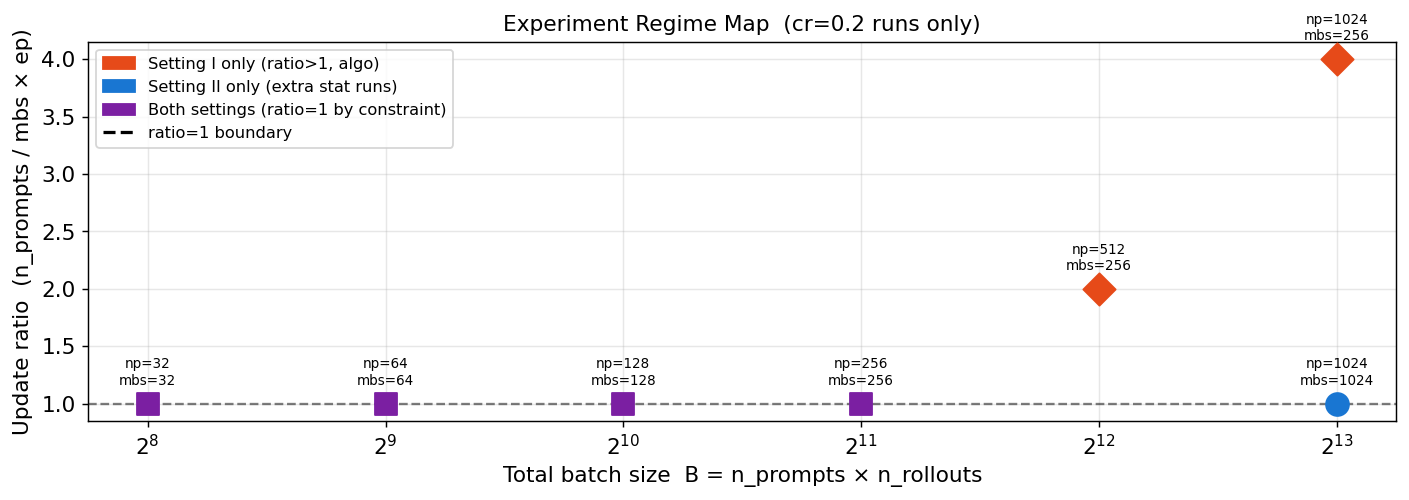

In [54]:
REGIME_COLOR  = {'statistical': '#1976D2', 'algorithmic': '#E64A19', 'both': '#7B1FA2'}
REGIME_MARKER = {'statistical': 'o',         'algorithmic': 'D',         'both': 's'}

fig, ax = plt.subplots(figsize=(11, 4))

for name, meta in sorted(experiments.items(), key=lambda x: x[1].get('total_batch', 0)):
    if abs(meta['clip_ratio'] - 0.2) > 1e-6:
        continue  # show cr=0.2 runs only (avoid visual noise)
    in_algo = name in algo_exps
    in_stat = name in stat_exps

    if in_algo and in_stat:
        color, marker, label = REGIME_COLOR['both'],         REGIME_MARKER['both'],         'Both (ratio=1)'
    elif in_algo:
        color, marker, label = REGIME_COLOR['algorithmic'],  REGIME_MARKER['algorithmic'],  'Algo only'
    elif in_stat:
        color, marker, label = REGIME_COLOR['statistical'],  REGIME_MARKER['statistical'],  'Stat only'
    else:
        continue

    B  = meta['total_batch']
    ur = meta['update_ratio']
    ax.scatter(B, ur, color=color, marker=marker, s=160, zorder=5)
    ax.annotate(f"np={meta['n_prompts']}\nmbs={meta['mbs_eff']}",
                (B, ur), fontsize=7.5, ha='center', va='bottom',
                xytext=(0, 9), textcoords='offset points')

ax.axhline(1.0, color='k', ls='--', lw=1.3, alpha=.5, label='ratio=1 boundary')
ax.set_xscale('log', base=2)
ax.set_xlabel('Total batch size  B = n_prompts × n_rollouts', fontsize=12)
ax.set_ylabel('Update ratio  (n_prompts / mbs × ep)', fontsize=12)
ax.set_title('Experiment Regime Map  (cr=0.2 runs only)', fontsize=12)
ax.grid(alpha=.3)

handles = [
    mpatches.Patch(color=REGIME_COLOR['algorithmic'],  label='Setting I only (ratio>1, algo)'),
    mpatches.Patch(color=REGIME_COLOR['statistical'],  label='Setting II only (extra stat runs)'),
    mpatches.Patch(color=REGIME_COLOR['both'],         label='Both settings (ratio=1 by constraint)'),
    Line2D([0],[0], color='k', ls='--', label='ratio=1 boundary'),
]
ax.legend(handles=handles, fontsize=9, loc='upper left')
plt.tight_layout()
plt.savefig('fig_cross_regime_map.pdf', bbox_inches='tight')
plt.show()

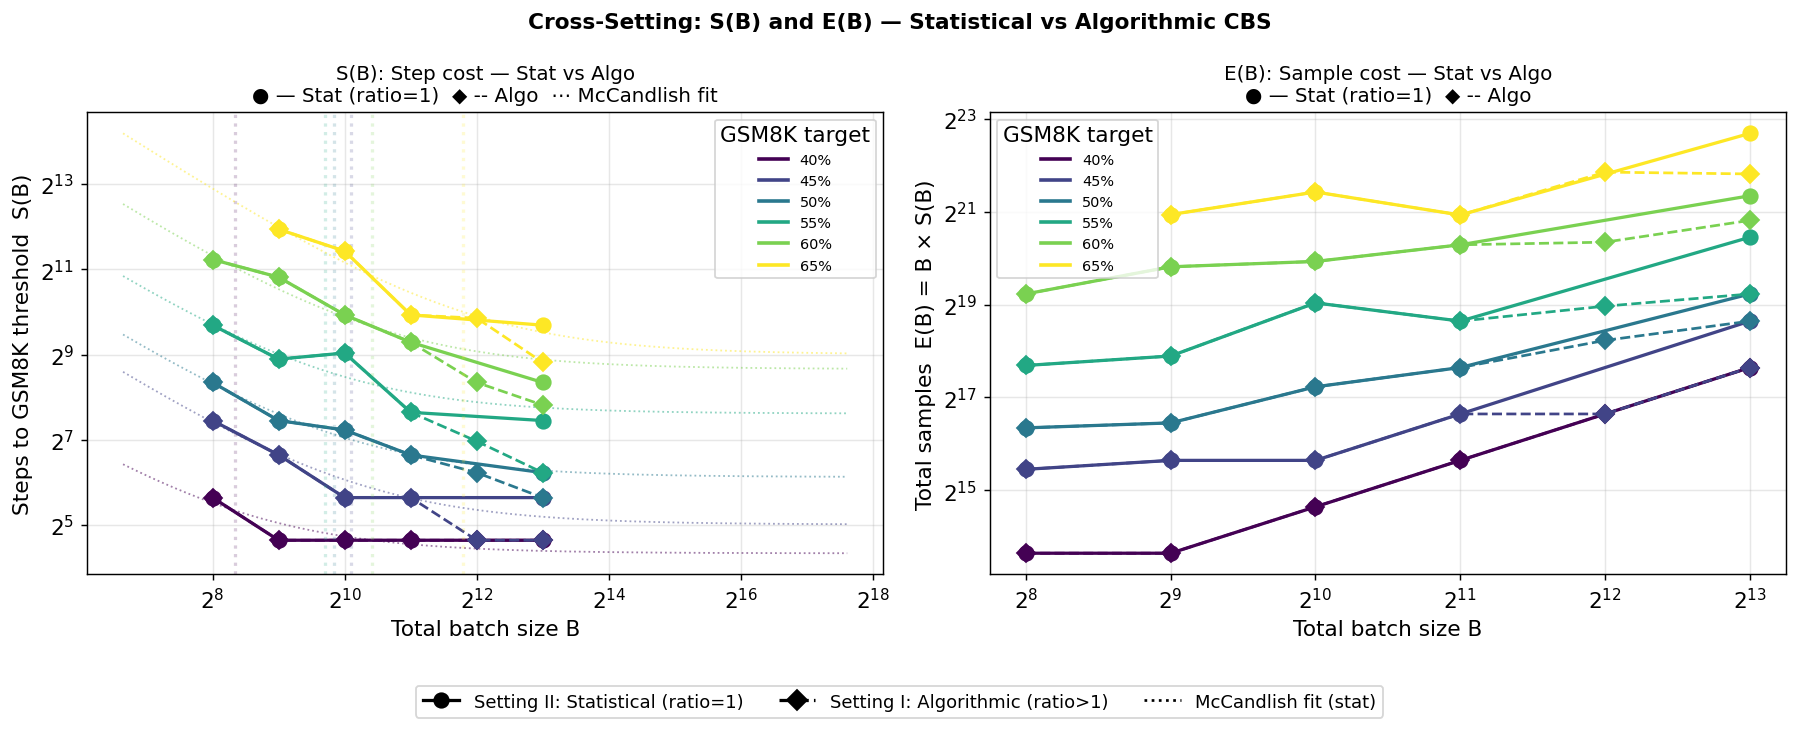

In [55]:
# S(B) and E(B): Statistical (solid ●) vs Algorithmic (dashed ◆)
sb_algo_cross = compute_sb(algo_exps, GSM8K_COL, gsm_thrs)
sb_stat_cross = compute_sb(stat_exps, GSM8K_COL, gsm_thrs)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

for thr in gsm_thrs:
    c = thr_colors[thr]

    sub_s = sb_stat_cross[(sb_stat_cross['threshold']==thr) & sb_stat_cross['S_B'].notna()].sort_values('B')
    sub_a = sb_algo_cross[(sb_algo_cross['threshold']==thr) & sb_algo_cross['S_B'].notna()].sort_values('B')

    if not sub_s.empty:
        axes[0].plot(sub_s['B'], sub_s['S_B'], 'o-',  color=c, ms=8, lw=1.8)
        axes[1].plot(sub_s['B'], sub_s['E_B'], 'o-',  color=c, ms=8, lw=1.8)
    if not sub_a.empty:
        axes[0].plot(sub_a['B'], sub_a['S_B'], 'D--', color=c, ms=7, lw=1.5)
        axes[1].plot(sub_a['B'], sub_a['E_B'], 'D--', color=c, ms=7, lw=1.5)
    # McCandlish fit overlay (statistical)
    if thr in stat_fits:
        f     = stat_fits[thr]
        B_p   = np.geomspace(100, 200_000, 300)
        axes[0].plot(B_p, mccandlish_S(B_p, f['S_min'], f['B_noise']),
                     color=c, ls=':', lw=1, alpha=.5)
        axes[0].axvline(f['B_noise'], color=c, ls=':', alpha=.2)

for ax, ylabel, title in [
    (axes[0], 'Steps to GSM8K threshold  S(B)',
     'S(B): Step cost — Stat vs Algo\n● — Stat (ratio=1)  ◆ -- Algo  ⋯ McCandlish fit'),
    (axes[1], 'Total samples  E(B) = B × S(B)',
     'E(B): Sample cost — Stat vs Algo\n● — Stat (ratio=1)  ◆ -- Algo'),
]:
    ax.set_xscale('log', base=2)
    ax.set_yscale('log', base=2)
    ax.set_xlabel('Total batch size B', fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(title, fontsize=11)
    ax.grid(alpha=.3, which='both')
    ax.legend(
        handles=[Line2D([0],[0], color=thr_colors[t], lw=2, label=f'{t:.0%}') for t in gsm_thrs],
        title='GSM8K target', fontsize=8)

fig.legend(handles=[
    Line2D([0],[0], color='k', ls='-',  marker='o', ms=8, label='Setting II: Statistical (ratio=1)'),
    Line2D([0],[0], color='k', ls='--', marker='D', ms=8, label='Setting I: Algorithmic (ratio>1)'),
    Line2D([0],[0], color='k', ls=':',              lw=1.5, label='McCandlish fit (stat)'),
], loc='lower center', ncol=3, fontsize=10, bbox_to_anchor=(0.5, -0.02))
plt.suptitle('Cross-Setting: S(B) and E(B) — Statistical vs Algorithmic CBS',
             fontsize=12, fontweight='bold')
plt.tight_layout(rect=[0, 0.07, 1, 1])
plt.savefig('fig_cross_sb_eb.pdf', bbox_inches='tight')
plt.show()

Runs at np=1024, cr=0.2, ep=1:
  cbs_p1_np1024_nr8_lr1e-6  mbs=256  ratio=4×  B=8192
  cbs_p1_np1024_nr8_lr1e-6_mbs1024  mbs=1024  ratio=1×  B=8192


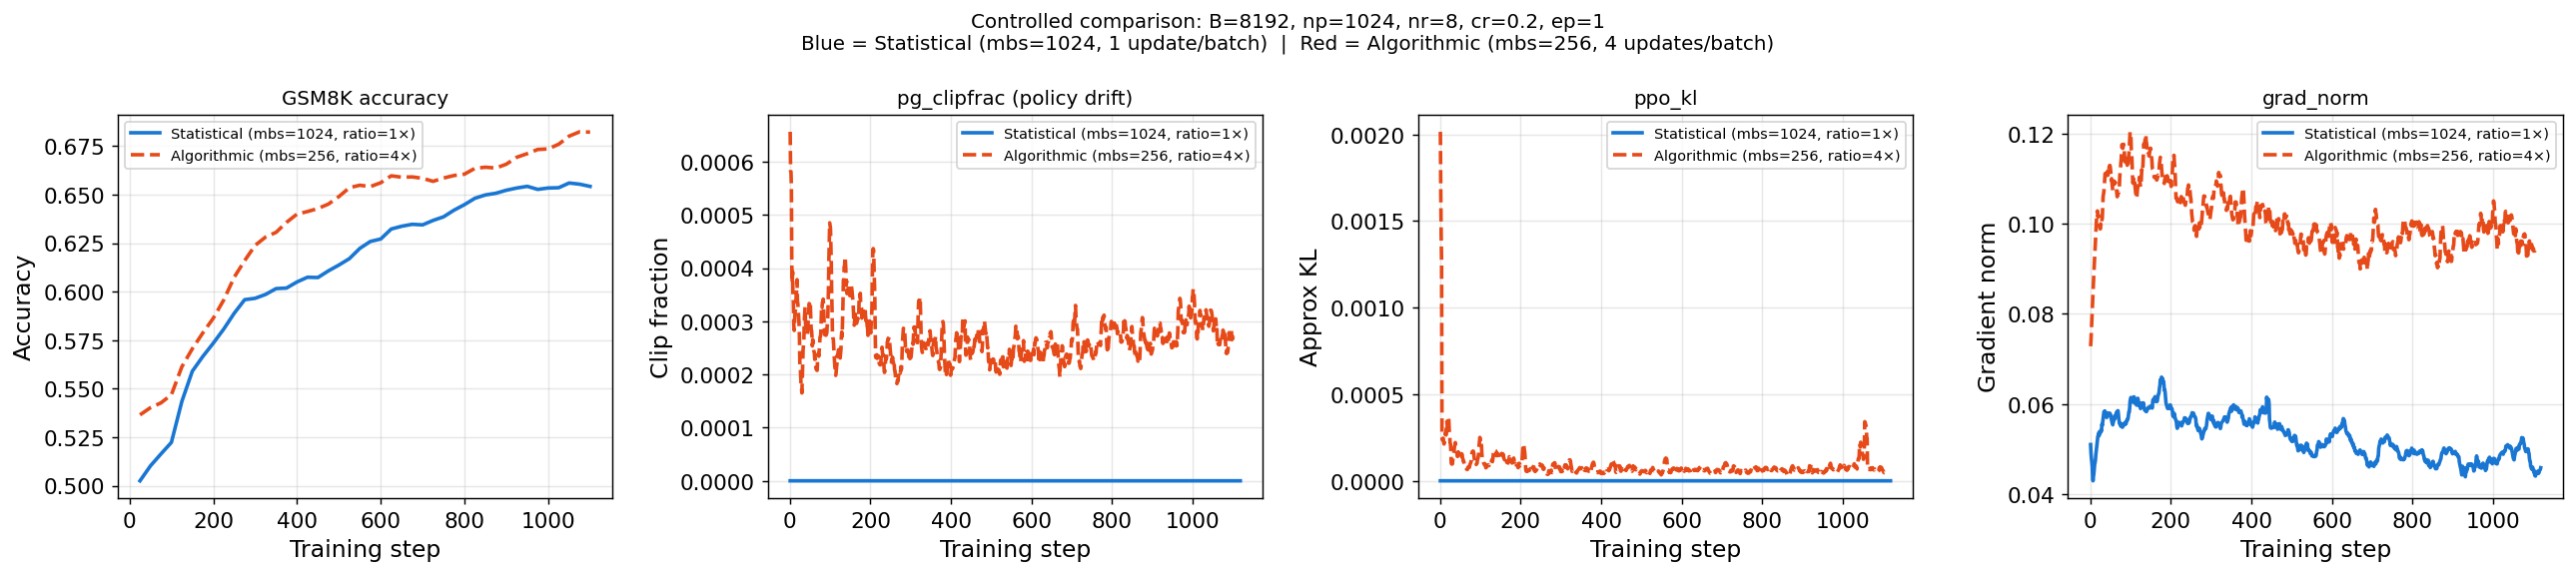

In [56]:
# Controlled: same B=8192 (np=1024, nr=8), stat (mbs=1024, ratio=1) vs algo (mbs=256, ratio=4)
controlled = {k: v for k, v in experiments.items()
              if v.get('n_prompts') == 1024
              and abs(v['clip_ratio'] - 0.2) < 1e-6
              and v['ppo_epochs'] == 1}

print('Runs at np=1024, cr=0.2, ep=1:')
for k, v in controlled.items():
    print(f'  {k}  mbs={v["mbs_eff"]}  ratio={v["update_ratio"]:.0f}×  B={v["total_batch"]}')

if len(controlled) >= 2:
    fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))

    for name, meta in sorted(controlled.items(), key=lambda x: x[1]['update_ratio']):
        hist   = meta['history']
        ur     = meta['update_ratio']
        is_stat = abs(ur - 1.0) < 0.01
        color  = '#1976D2' if is_stat else '#E64A19'
        ls     = '-'       if is_stat else '--'
        lbl    = (f"Statistical (mbs={meta['mbs_eff']}, ratio=1×)"
                  if is_stat else
                  f"Algorithmic (mbs={meta['mbs_eff']}, ratio={ur:.0f}×)")

        for ax, col in zip(axes, [GSM8K_COL, CLIPFRAC_COL, KL_COL, GRADNORM_COL]):
            df = hist[[STEP_COL, col]].dropna().sort_values(STEP_COL)
            if df.empty: continue
            ax.plot(df[STEP_COL], smooth(df[col], 7), color=color, ls=ls, label=lbl, lw=2)

    for ax, title, ylabel in zip(
        axes,
        ['GSM8K accuracy', 'pg_clipfrac (policy drift)', 'ppo_kl', 'grad_norm'],
        ['Accuracy', 'Clip fraction', 'Approx KL', 'Gradient norm'],
    ):
        ax.set_xlabel('Training step')
        ax.set_ylabel(ylabel)
        ax.set_title(title, fontsize=11)
        ax.legend(fontsize=8)
        ax.grid(alpha=.3)

    plt.suptitle(
        'Controlled comparison: B=8192, np=1024, nr=8, cr=0.2, ep=1\n'
        'Blue = Statistical (mbs=1024, 1 update/batch)  |  '
        'Red = Algorithmic (mbs=256, 4 updates/batch)',
        fontsize=11)
    plt.tight_layout()
    plt.savefig('fig_cross_controlled_comparison.pdf', bbox_inches='tight')
    plt.show()
else:
    print('\nNeed both stat (mbs=1024) and algo (mbs=256) runs at np=1024 for controlled comparison.')
    print('Run the on-policy np=1024 experiment to enable this analysis.')

---
## Summary

### Research Questions

| Question | Setting | Diagnostic | Expected Result |
|---|---|---|---|
| Does RLVR have a *statistical* CBS? | II | McCandlish S(B) fit | Sub-linear S(B) → yes |
| What is B* (statistical CBS)? | II | B_noise from fit or gradient stats | B* ≈ B_noise |
| Does multi-update hurt? | I | clipfrac, KL vs update_ratio | Both rise with ratio |
| What is the *algorithmic* CBS? | I | update_ratio where perf degrades | Elbow in accuracy vs ratio |
| Does clipping help? | III | cr=0.0 vs cr=0.2 accuracy | If cr=0.0 matches, clip unnecessary |
| Does stat vs algo matter at same B? | Cross | Controlled comparison | Stat should be more sample-efficient |

In [57]:
print('═' * 90)
print('FULL EXPERIMENT SUMMARY')
print('═' * 90)

sum_rows = []
for name, meta in sorted(experiments.items(),
                          key=lambda x: (x[1]['clip_ratio'],
                                         x[1]['update_ratio'],
                                         x[1].get('n_prompts', 0))):
    hist = meta['history']
    def _max(c): return round(hist[c].dropna().max(), 3)    if c in hist.columns and not hist[c].dropna().empty else float('nan')
    def _med(c): return round(hist[c].dropna().median(), 4) if c in hist.columns and not hist[c].dropna().empty else float('nan')

    flags = []
    if name in algo_exps: flags.append('I-Algo')
    if name in stat_exps: flags.append('II-Stat')
    if name in clip_exps: flags.append('III-Clip')

    sum_rows.append({
        'setting':    '+'.join(flags),
        'np':         meta['n_prompts'],
        'mbs':        meta['mbs_eff'],
        'ratio':      round(meta['update_ratio'], 1),
        'cr':         meta['clip_ratio'],
        'B':          meta.get('total_batch'),
        'steps':      int(hist[STEP_COL].dropna().max()) if STEP_COL in hist.columns else 0,
        'gsm8k':      _max(GSM8K_COL),
        'math':       _max(MATH_COL),
        'med_cf':     _med(CLIPFRAC_COL),
        'med_kl':     _med(KL_COL),
    })

df_sum = pd.DataFrame(sum_rows)
print(df_sum.to_string(index=False))

══════════════════════════════════════════════════════════════════════════════════════════
FULL EXPERIMENT SUMMARY
══════════════════════════════════════════════════════════════════════════════════════════
       setting   np  mbs  ratio  cr    B  steps  gsm8k  math  med_cf  med_kl
      III-Clip 1024  256    4.0 0.0 8192    946  0.679 0.151  0.0002  0.0001
I-Algo+II-Stat   32   32    1.0 0.2  256   5968  0.645 0.140  0.0000  0.0000
I-Algo+II-Stat   64   64    1.0 0.2  512   8696  0.686 0.157  0.0000  0.0000
I-Algo+II-Stat  128  128    1.0 0.2 1024   7710  0.694 0.153  0.0000  0.0000
I-Algo+II-Stat  256  256    1.0 0.2 2048   3152  0.674 0.143  0.0000  0.0000
       II-Stat 1024 1024    1.0 0.2 8192   1118  0.662 0.161  0.0000  0.0000
        I-Algo  512  256    2.0 0.2 4096   2020  0.683 0.149  0.0001  0.0000
        I-Algo 1024  256    4.0 0.2 8192   1103  0.688 0.156  0.0003  0.0001


In [58]:
print('\n' + '─' * 60)
print('McCandlish fit — Setting II (Statistical CBS, GSM8K, cr=0.2, ep=1):')
print('─' * 60)
if stat_fits:
    for thr, f in sorted(stat_fits.items()):
        print(f'  thr={thr:.0%}  B* = {f["B_noise"]:>7.0f}  S_min = {f["S_min"]:>6.1f}  R² = {f["R2"]:.3f}')
    b_stars = [f['B_noise'] for f in stat_fits.values()]
    print(f'\n  Median B* across thresholds: {np.median(b_stars):.0f}')
    print(f'  (Interpretation: B* is the statistical CBS — marginal gain from larger B drops above B*)')
else:
    print('  No fits available. Need ≥3 batch sizes reaching each threshold.')

print('\n' + '─' * 60)
print('Setting I — Algorithmic CBS diagnostics:')
print('─' * 60)
if not diag_algo.empty:
    print(diag_algo[['np','B','update_ratio','med_clipfrac','med_kl',
                      'gsm8k_best','math_best']].to_string(index=False))
    # Find elbow: ratio where clipfrac first exceeds 2× its ratio=1 value
    baseline_cf = diag_algo[diag_algo['update_ratio'] == 1.0]['med_clipfrac'].values
    if len(baseline_cf):
        elbow = diag_algo[diag_algo['med_clipfrac'] > 2 * baseline_cf[0]]
        if not elbow.empty:
            print(f'\n  Algorithmic CBS signal: clip fraction > 2× baseline at ratio = {elbow["update_ratio"].iloc[0]:.0f}×')
        else:
            print('\n  No clear algorithmic CBS elbow detected within observed update ratios.')


────────────────────────────────────────────────────────────
McCandlish fit — Setting II (Statistical CBS, GSM8K, cr=0.2, ep=1):
────────────────────────────────────────────────────────────
  thr=40%  B* =     325  S_min =   20.2  R² = 0.795
  thr=45%  B* =    1096  S_min =   32.3  R² = 0.960
  thr=50%  B* =     914  S_min =   69.9  R² = 0.981
  thr=55%  B* =     836  S_min =  196.0  R² = 0.867
  thr=60%  B* =    1364  S_min =  404.2  R² = 0.949
  thr=65%  B* =    3541  S_min =  512.5  R² = 0.937

  Median B* across thresholds: 1005
  (Interpretation: B* is the statistical CBS — marginal gain from larger B drops above B*)

────────────────────────────────────────────────────────────
Setting I — Algorithmic CBS diagnostics:
────────────────────────────────────────────────────────────
  np    B  update_ratio  med_clipfrac   med_kl  gsm8k_best  math_best
 256 2048           1.0      0.000000 0.000000       0.674   0.143287
  32  256           1.0      0.000000 0.000000       0.645   0.14